In [2]:

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import fitsio
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
import scienceplots
plt.style.use(['science','notebook','grid'])
import glob
import os
from astropy.table import Table

In [6]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

#plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

#plt.plot(samples_sorted,y_samples_sorted,'.',alpha=0.6)
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

def r_to_theta(r_mpc):
    return np.rad2deg(r_mpc / chi_eff)


In [3]:
chi_eff

389.03040493043204

In [ ]:
dl_zeff

NameError: name 'dl_zeff' is not defined

In [7]:
zeff = np.trapz(z*n_z, z) /np.trapz(n_z, z)
print('zeff = ', zeff)
dc_zeff= cosmo.comoving_distance(zeff).to(u.Mpc).value
dc_zeff

def theta_to_r_dc(theta_deg):
    return dc_zeff * np.deg2rad(theta_deg)
def r_to_theta_dc(r_mpc):
    return np.rad2deg(r_mpc / dc_zeff)

zeff =  0.09106798656748412


In [8]:
#files

files_point = np.sort([file for file in files if  'jackknife'  not in file and 'bootstrap' not in file and  '0.001_to_100' in file ])
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_south_0.001_to_100.npy'],
      dtype='<U82')

In [9]:
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_full_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/treecorr_south_0.001_to_100.npy'],
      dtype='<U82')

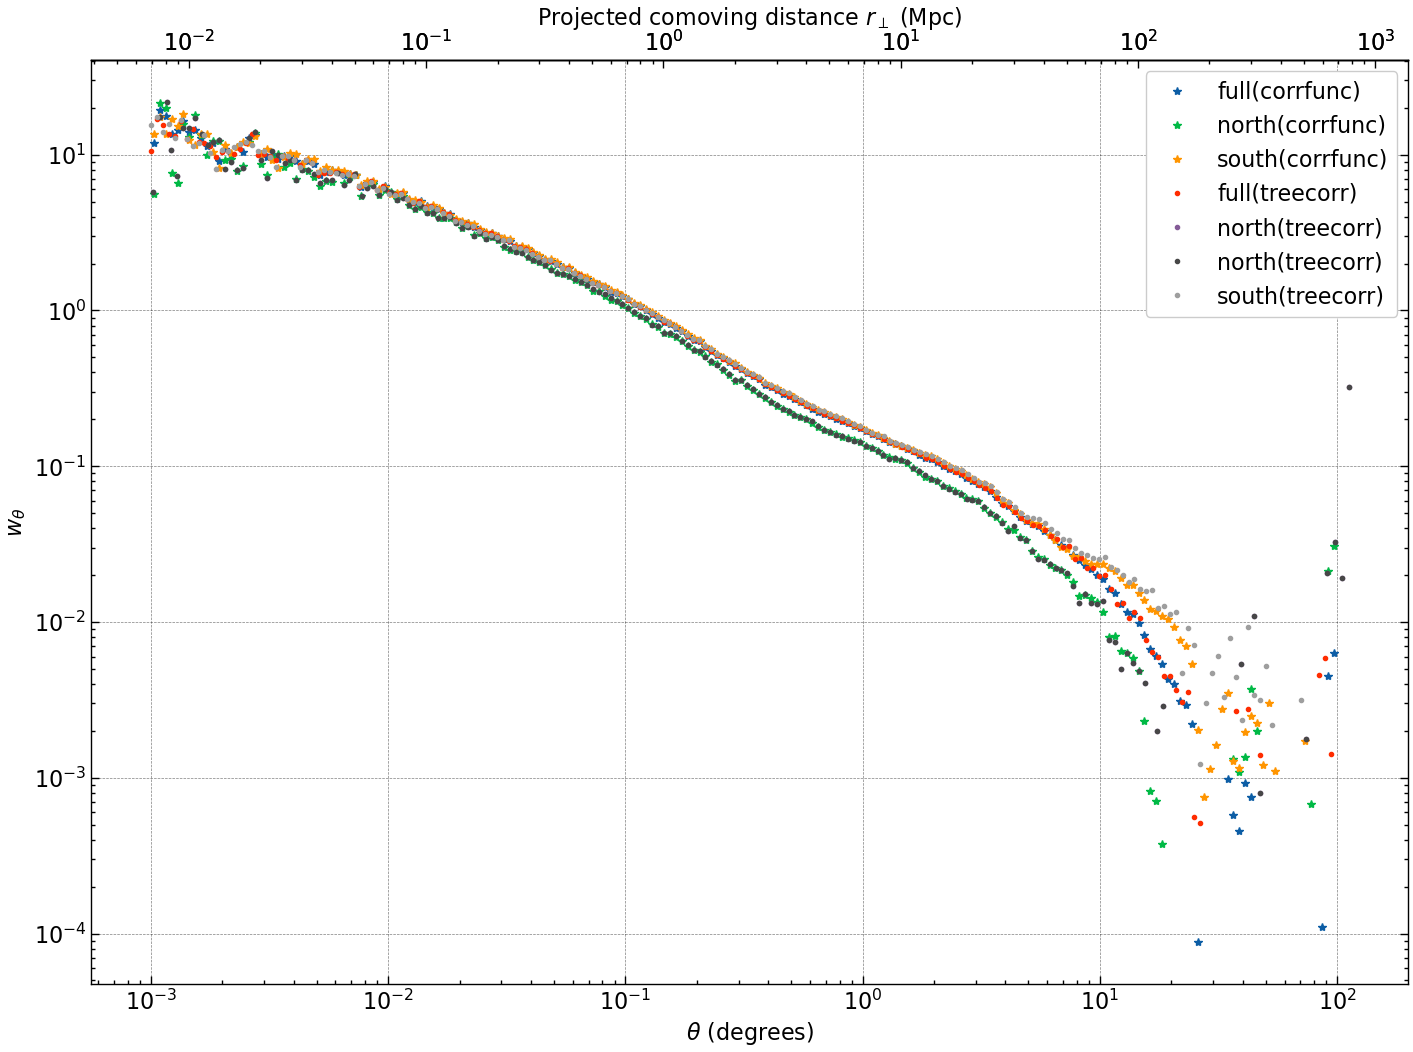

In [10]:
color = ['k','r','b','g']
fig,ax = plt.subplots(figsize=(17,12))
for file in files_point: 
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    if  'corrfunc' in name:
        ax.plot(dat[0],dat[1],label=name,marker='*',linestyle='None')
    else: 
        ax.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
    #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')

plt.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

In [ ]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# plt.figure(figsize=(15,10))
# files = [file for file in files if '100' in file]
# color = ['k','r','b','g']
# for file in files: 

#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()

/tmp/ipykernel_81987/3596371664.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


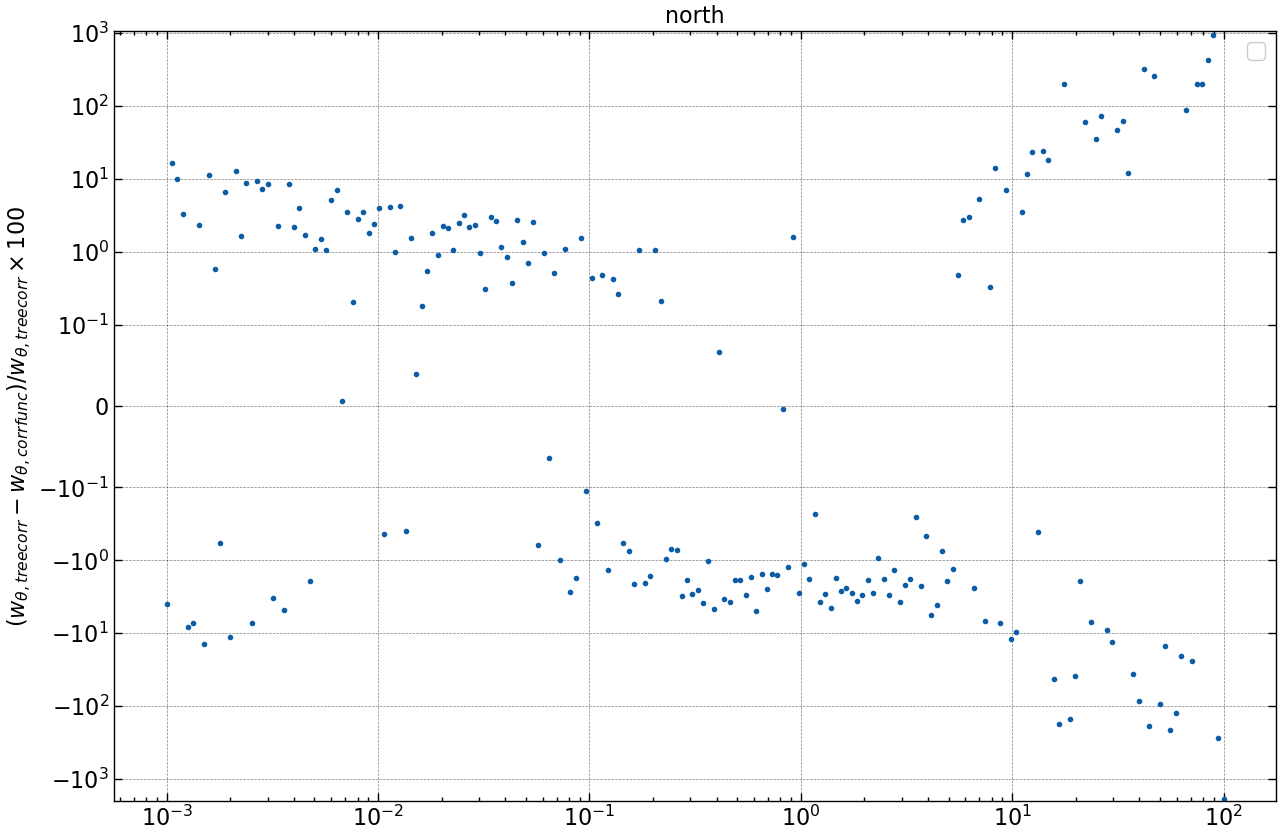

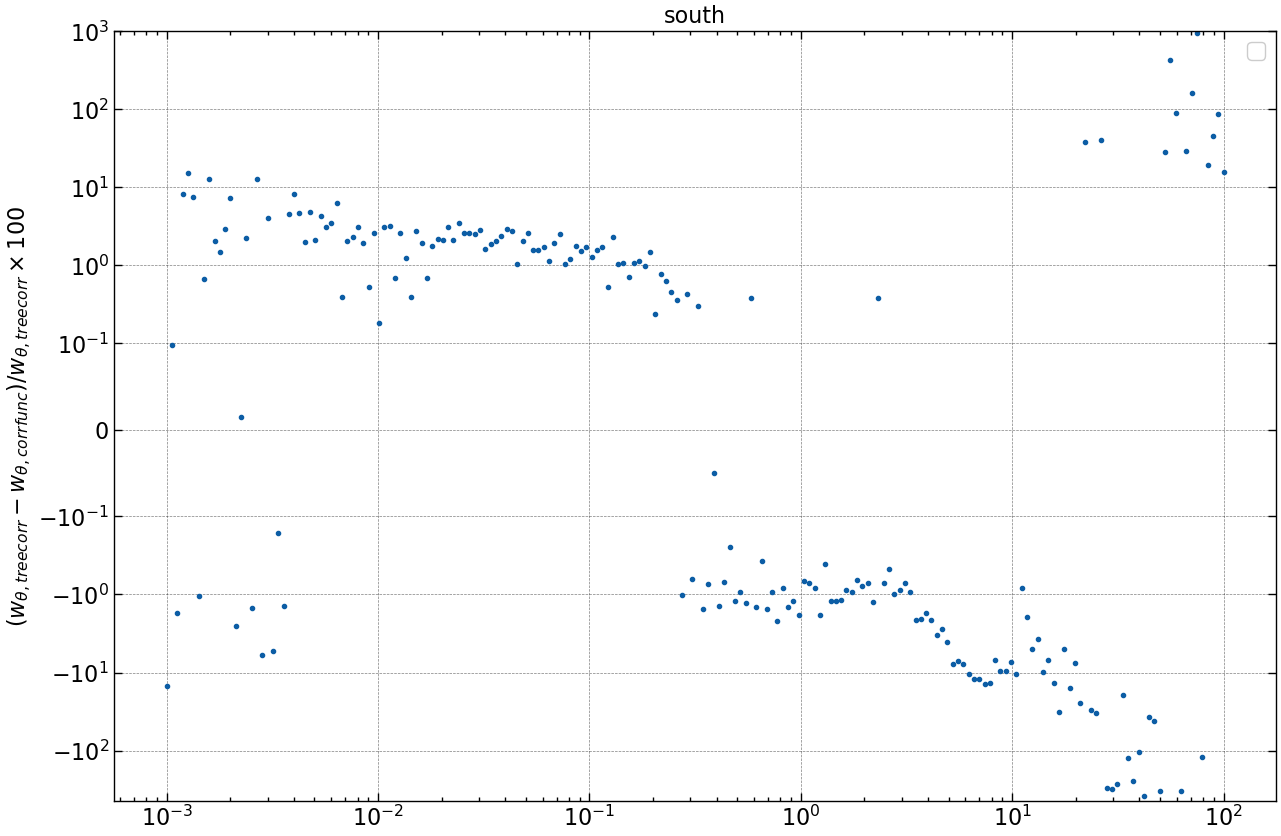

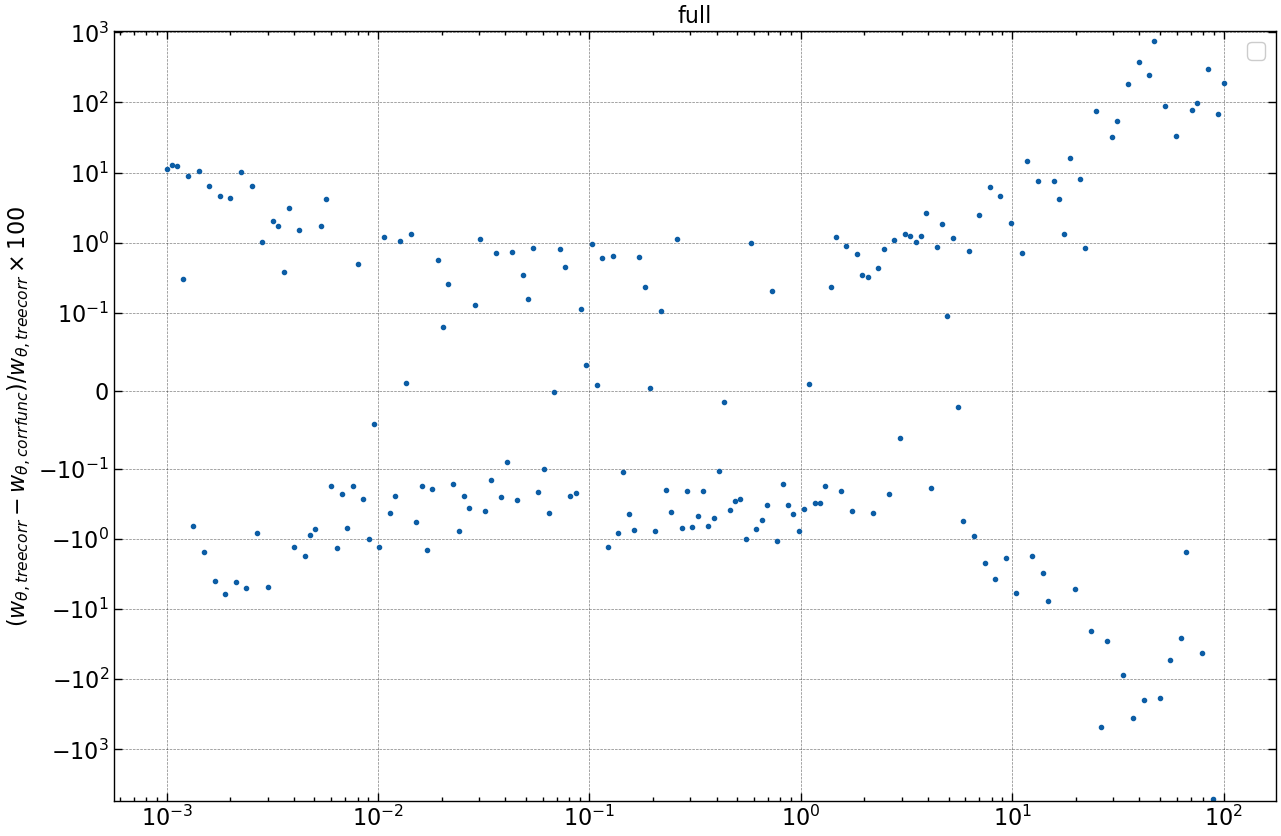

In [ ]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files = [file for file in files if '100' in file]


part = ['north','south','full']


{patch: [file for file in files if patch in file] for patch in part}


for patch in part:
    plt.figure(figsize=(15,10))

    files_sub = [file for file in files if patch in file]
    ar = []
    for file in files_sub:
        dat = np.load(file)
        name = os.path.basename(file)
        name = name.replace('.npy','')
        name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
        ar.append(dat[1])
        #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
    plt.plot(dat[0],100*(ar[0]-ar[1])/ar[0],'.')
    plt.ylabel(r'$(w_{\theta, treecorr} - w_{\theta, corrfunc})/w_{\theta, treecorr} \times 100$')
    plt.xscale('log')
    plt.yscale('symlog', linthresh=0.1)

    plt.title(patch)
    plt.legend()
    plt.show()


# for file in files: 
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

#   if 'north' in name:
#         ar1 = 

        
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


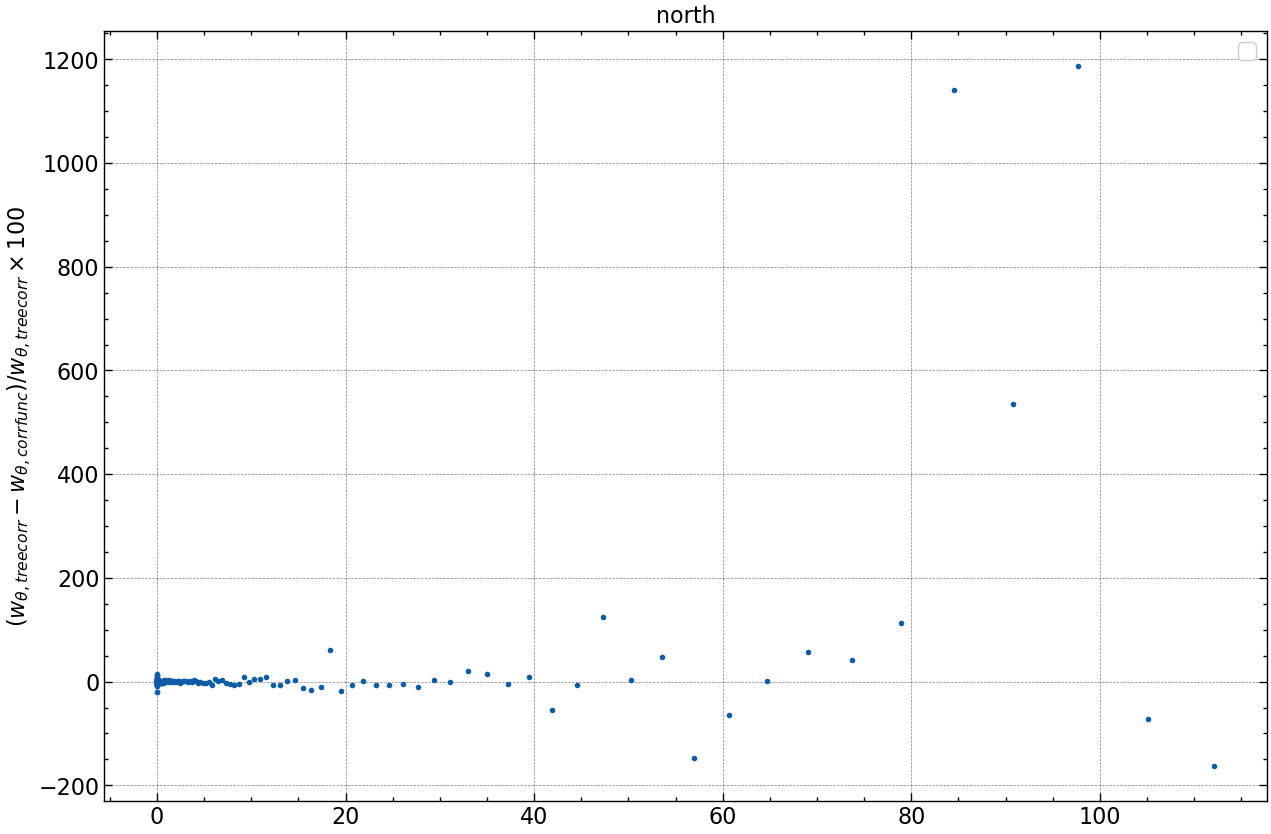

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


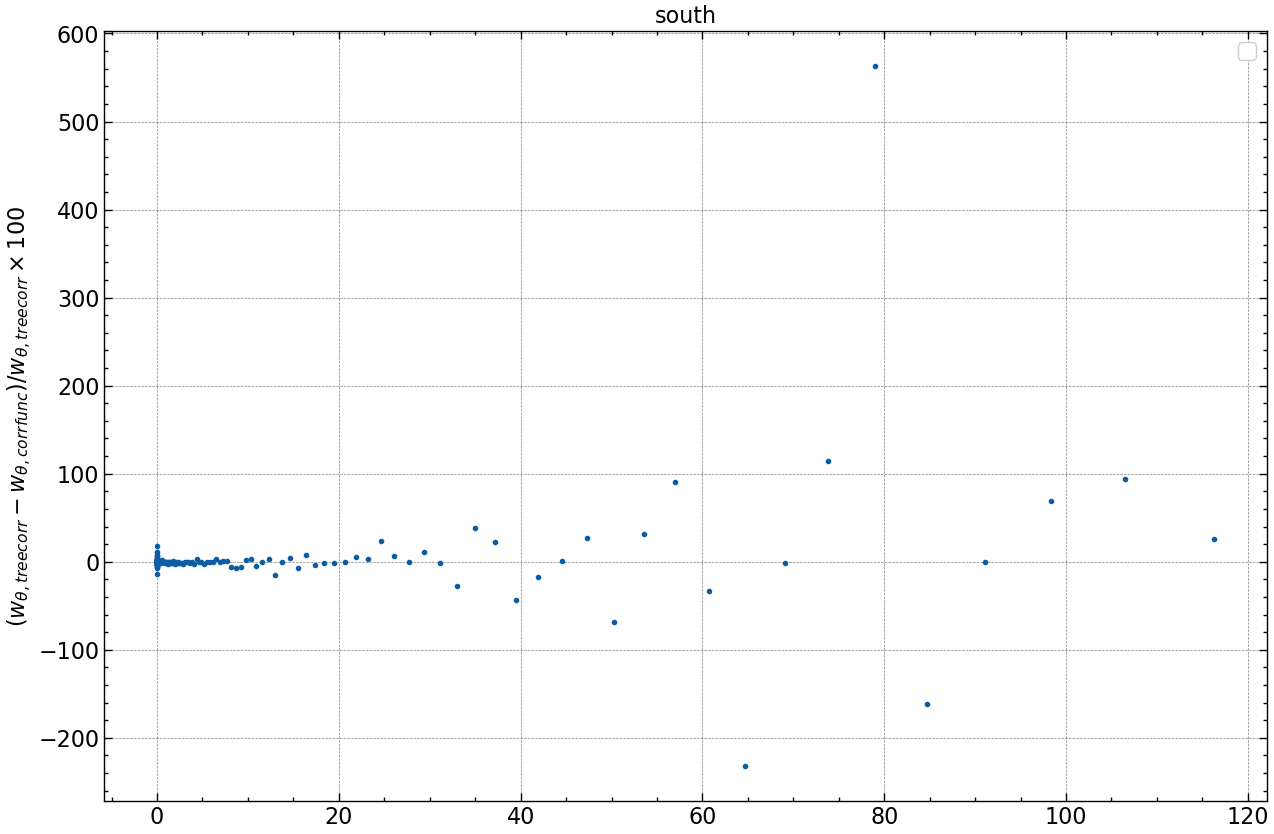

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


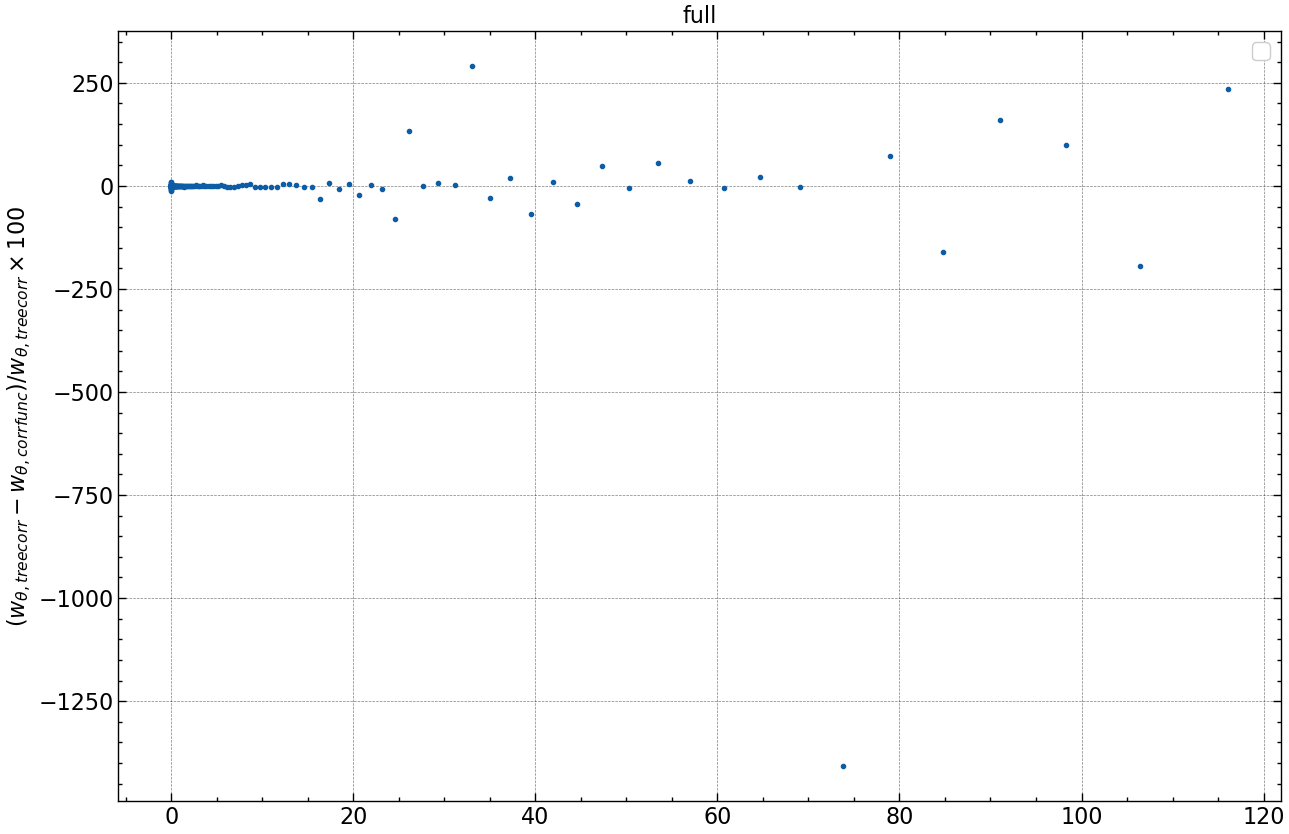

In [ ]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files = [file for file in files if '100' in file]


part = ['north','south','full']


{patch: [file for file in files if patch in file] for patch in part}


for patch in part:
    plt.figure(figsize=(15,10))

    files_sub = [file for file in files if patch in file]
    ar = []
    for file in files_sub:
        dat = np.load(file)
        name = os.path.basename(file)
        name = name.replace('.npy','')
        name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
        ar.append(dat[1])
        #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
    plt.plot(dat[0],100*(ar[0]-ar[1])/ar[0],'.')
    plt.ylabel(r'$(w_{\theta, treecorr} - w_{\theta, corrfunc})/w_{\theta, treecorr} \times 100$')
    # plt.xscale('log')
    # plt.yscale('symlog', linthresh=0.1)

    plt.title(patch)
    plt.legend()
    plt.show()


# for file in files: 
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

#   if 'north' in name:
#         ar1 = 

        
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()


In [ ]:
files_jackknife

NameError: name 'files_jackknife' is not defined

NameError: name 'theta_deg' is not defined

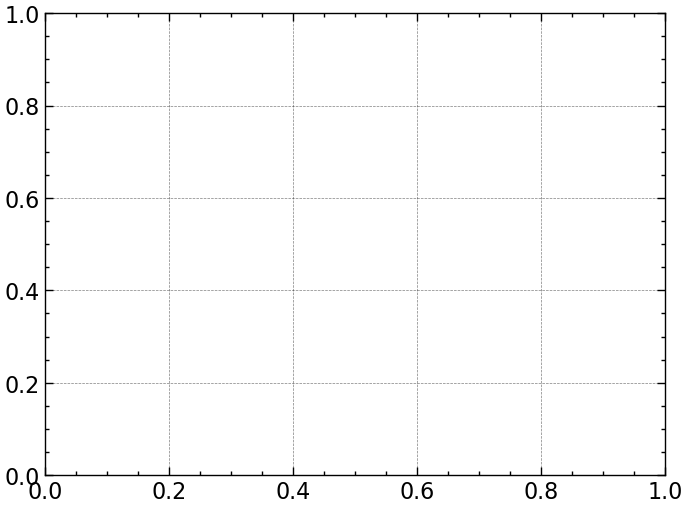

In [ ]:
fig, ax = plt.subplots()
ax.loglog(theta_deg, omega_theta, marker='o')
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'$w(\theta)$')

# add distance top axis
secax = ax.secondary_xaxis('top',
    functions=(theta_to_r, r_to_theta))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')


In [ ]:
r_to_theta(1)

0.1472746965654645

In [ ]:
theta_to_r(0.147)

0.9981348013482928

In [ ]:
r_to_theta(np.array([1,2,3,4]))

array([0.1472747 , 0.29454939, 0.44182409, 0.58909879])

In [ ]:
files_jackknife_200[0]
files_bootstrap[0]

jk= np.load(files_jackknife_200[0])
b = np.load(files_bootstrap[0])
fig, ax = plt.subplots(figsize=(15,10))
ax.errorbar(b[0][::2],b[1][::2],yerr=b[2][::2],label='bootstrap',marker='*',linestyle='None',capsize=3,alpha=0.8)
ax.errorbar(jk[0][::2],jk[1][::2],yerr=jk[2][::2],label='jackknife',marker='o',linestyle='None',capsize=3,alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
ax.set_yscale('log')
plt.legend()


NameError: name 'files_jackknife_200' is not defined

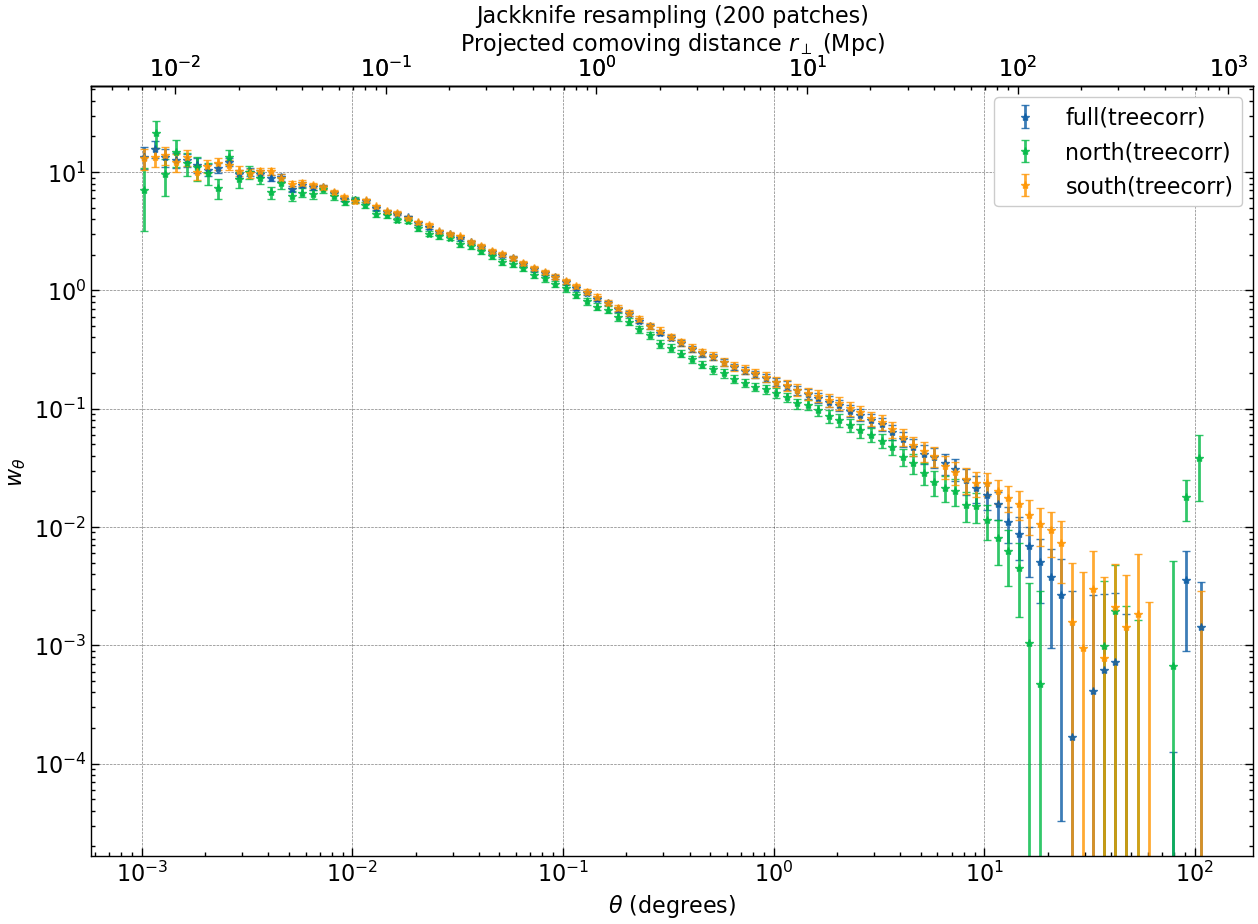

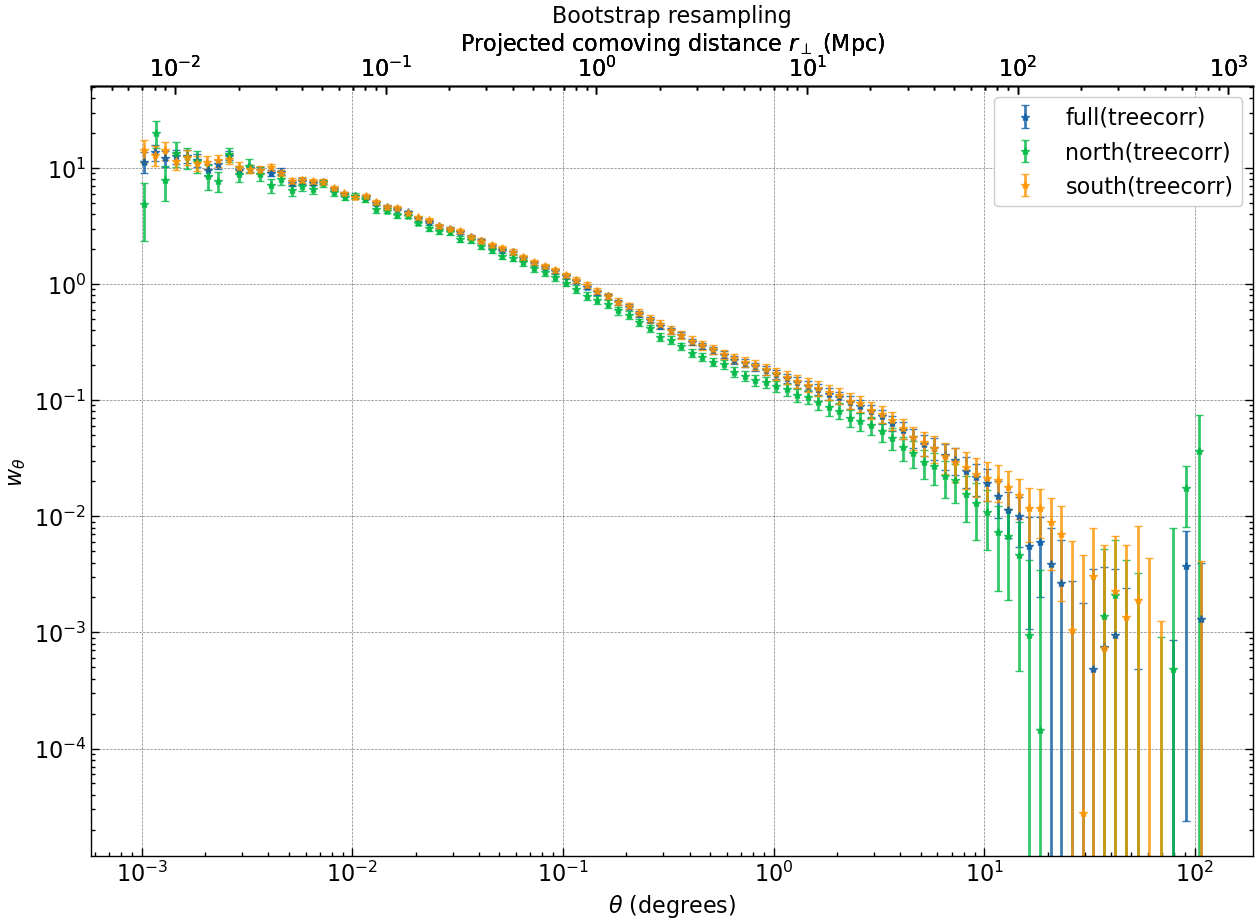

In [7]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files_jackknife_200 = np.sort([file for file in files if  'jackknife'  in file and '200' in file])

files_bootstrap = np.sort([file for file in files if  'bootstrap'  in file])
#part = ['north','south','full']


#{patch: [file for file in files if patch in file] for patch in part}

#plt.figure(figsize=(15,10))
fig, ax = plt.subplots(figsize=(15,10))

for file in files_jackknife_200:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (200 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()


fig, ax = plt.subplots(figsize=(15,10))

for file in files_bootstrap:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Bootstrap resampling')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\theta$ (degrees)')
    ax.set_ylabel(r'$w_{\theta}$')
    secax = ax.secondary_xaxis('top',
    functions=(theta_to_r_dc,r_to_theta_dc))
    secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

plt.legend()


# for file in files: 
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

#   if 'north' in name:
#         ar1 = 

        
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()


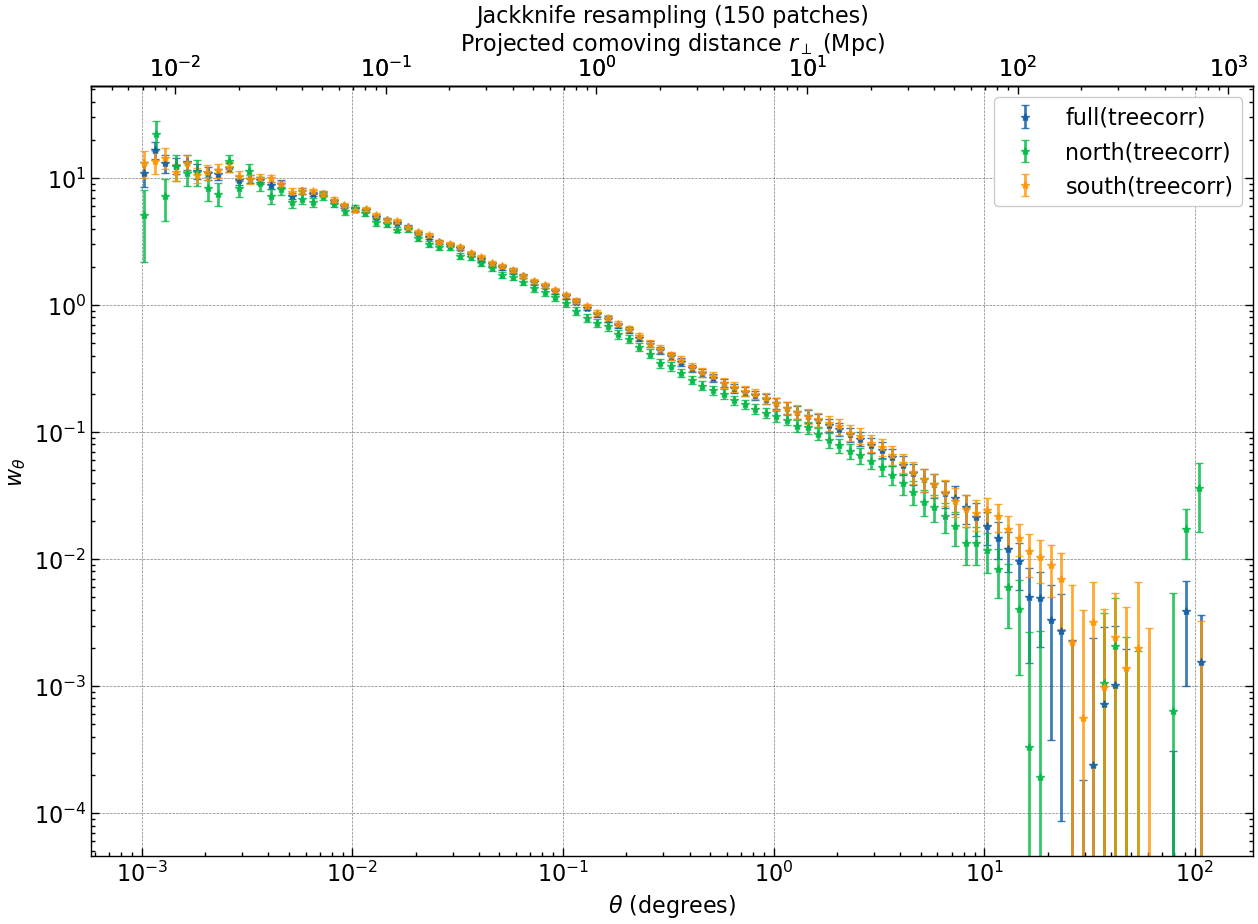

In [ ]:

files_jackknife_150 = [file for file in files if  'jackknife'  in file and '150' in file]



#{patch: [file for file in files if patch in file] for patch in part}

fig, ax = plt.subplots(figsize=(15,10))
for file in files_jackknife_150:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (150 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

In [ ]:
files_jackknife


[]

In [ ]:
files

['/user/animesh.sah/w_theta_results/treecorr_north_0.001_to_10.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_patches_100_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/treecorr_full_0.001_to_10.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_full_jackknife_patches_150_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10.npy',
 '/user/animesh.sah/w_theta_results/treecorr_north_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_south_jackknife_patches_100_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_full_jackknife_patches_200_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_south_jackknife_patches_200_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_south_bootstrap_patches_100_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_result

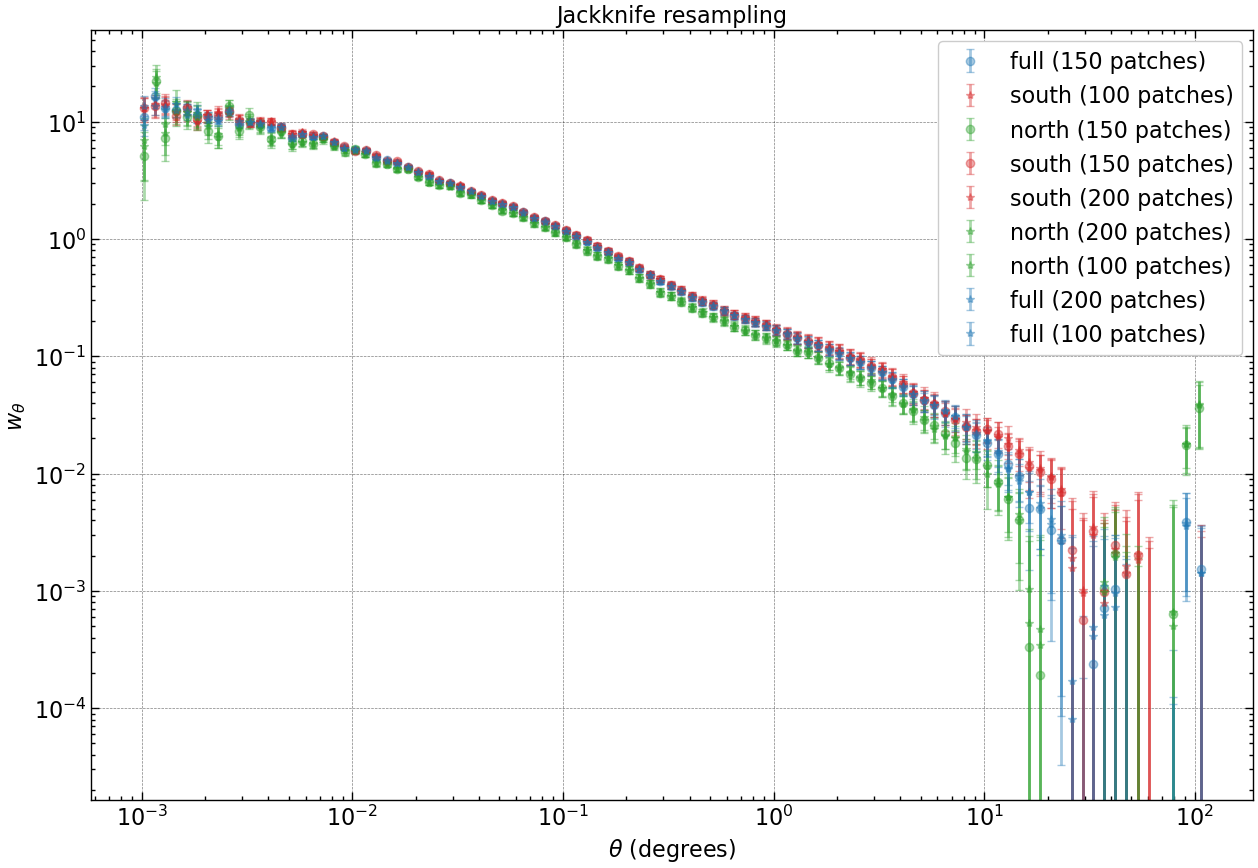

In [ ]:
files_jackknife = [file for file in files if  'jackknife'  in file and 'treecorr' in file]

plt.figure(figsize=(15,10))

region_colors = {
    "north": "tab:green",
    "south": "tab:red",
    "full":  "tab:blue"
}
patch_styles = {
    "150": {"marker": "o"},
    "200": {"marker": "*"}
}
for file in files_jackknife:
    dat = np.load(file)
    name = os.path.basename(file).replace(".npy", "")

    # parse region and patch number from filename
    parts = name.split("_")
    region = parts[1]   # full, south, north
    patchnum = parts[4] # 150 or 200

    color = region_colors.get(region, "black")
    style = patch_styles.get(patchnum, {"marker": "*", "linestyle": "None"})

    label = f"{region} ({patchnum} patches)"
    try:
        plt.errorbar(
            dat[0][::2], dat[1][::2], yerr=dat[2][::2],
            label=label,
            color=color,
            marker=style["marker"],
            linestyle='None',
            capsize=3,
            alpha=0.4
        )
    except Exception as e:
        print(f"Error plotting {name}: {e}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ (degrees)")
plt.ylabel(r"$w_{\theta}$")
plt.title("Jackknife resampling")
plt.legend()
plt.show()

In [8]:
np.log10(r_to_theta_dc(40)) , np.log10(20)

(0.7610292063004354, 1.3010299956639813)

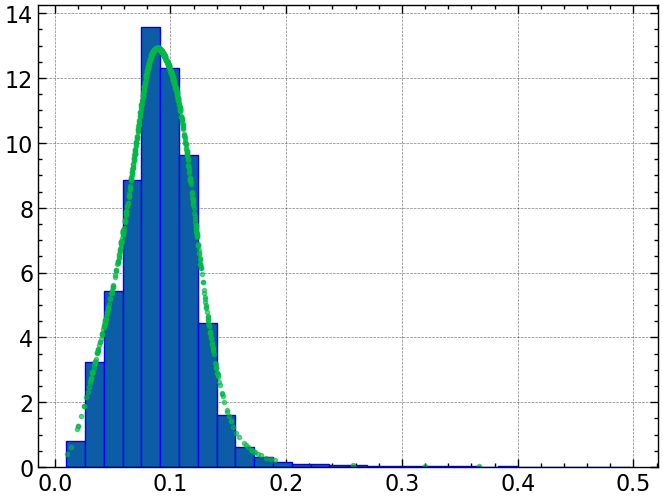

In [9]:
import pyccl as ccl

cosmo = ccl.Cosmology(
    Omega_c=0.25,  # Cold dark matter density
    Omega_b=0.05,  # Baryon density
    h=0.67,        # Hubble parameter
    sigma8=0.8,    # Power spectrum normalization
    n_s=0.96       # Spectral index
)
import numpy as np
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'.',alpha=0.6)
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)

In [10]:
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell = np.arange(2, 1000)
cl = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
theta = np.logspace(0.75, 1.2, 50)  # in radians (~0.06° to 57°)
wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)
wtheta

array([0.0085722 , 0.00829601, 0.00802571, 0.00776118, 0.00750246,
       0.00724951, 0.00700225, 0.00676069, 0.00652478, 0.00629445,
       0.00606971, 0.00585046, 0.0056367 , 0.00542835, 0.00522537,
       0.00502772, 0.00483532, 0.00464815, 0.00446612, 0.00428919,
       0.00411729, 0.00395037, 0.00378835, 0.00363119, 0.00347881,
       0.00333115, 0.00318814, 0.00304972, 0.00291582, 0.00278638,
       0.00266134, 0.00254062, 0.00242418, 0.00231196, 0.00220391,
       0.00209998, 0.00200013, 0.00190432, 0.00181253, 0.00172471,
       0.00164084, 0.00156088, 0.00148479, 0.00141248, 0.00134389,
       0.00127889, 0.00121733, 0.00115901, 0.00110371, 0.00105115])

In [11]:
theta

array([ 5.62341325,  5.74359321,  5.86634158,  5.99171324,  6.11976427,
        6.25055193,  6.38413469,  6.52057229,  6.65992576,  6.80225739,
        6.94763085,  7.09611113,  7.24776464,  7.40265918,  7.56086404,
        7.72244995,  7.88748916,  8.05605549,  8.22822431,  8.40407261,
        8.58367902,  8.76712387,  8.95448919,  9.14585875,  9.34131814,
        9.54095476,  9.74485789,  9.9531187 , 10.16583033, 10.3830879 ,
       10.60498855, 10.83163152, 11.06311816, 11.29955198, 11.54103872,
       11.78768635, 12.03960517, 12.29690784, 12.55970942, 12.82812743,
       13.10228189, 13.3822954 , 13.66829318, 13.96040312, 14.25875585,
       14.56348478, 14.87472617, 15.19261922, 15.51730607, 15.84893192])

In [12]:


from scipy.optimize import curve_fit as cf
def wfunc(theta,a):
    wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)

    return a*wtheta


wfunc(wtheta,1)

array([1.53722343, 1.55774247, 1.57661884, 1.59383765, 1.60953217,
       1.62397806, 1.63756834, 1.65077055, 1.66410433, 1.67810159,
       1.69327175, 1.71008498, 1.72893706, 1.75014582, 1.77393497,
       1.80042954, 1.82966278, 1.86156882, 1.89604537, 1.93283744,
       1.97169241, 2.01236582, 2.05442592, 2.09761378, 2.14152925,
       2.18579626, 2.23004384, 2.27405879, 2.31752215, 2.36009345,
       2.40149623, 2.44166348, 2.48041239, 2.51763718, 2.55293338,
       2.58659421, 2.61818943, 2.64815719, 2.6761933 , 2.70221978,
       2.72624128, 2.74876119, 2.76953248, 2.78837589, 2.80544317,
       2.82155195, 2.83614256, 2.84922176, 2.86085456, 2.87183739])

[5.33954093]
[5.33954093]


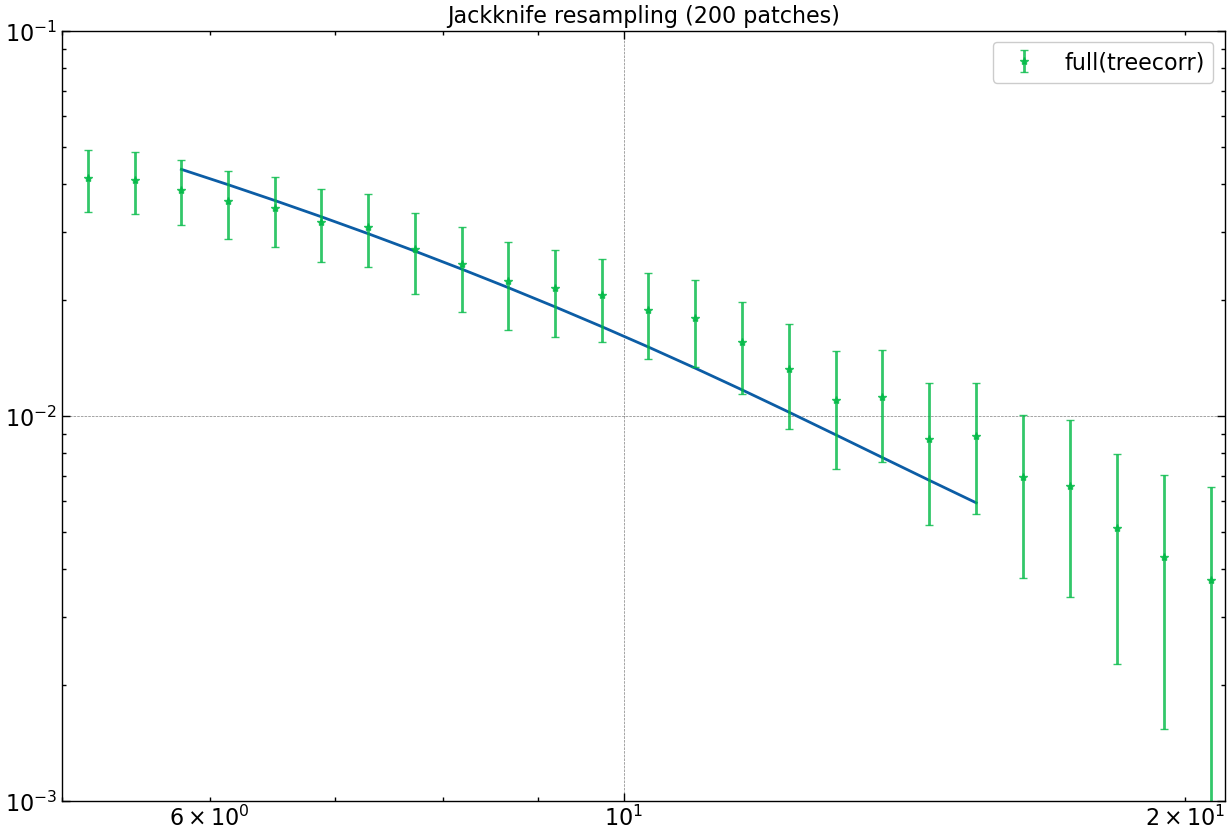

[3.30201726]
[3.30201726]


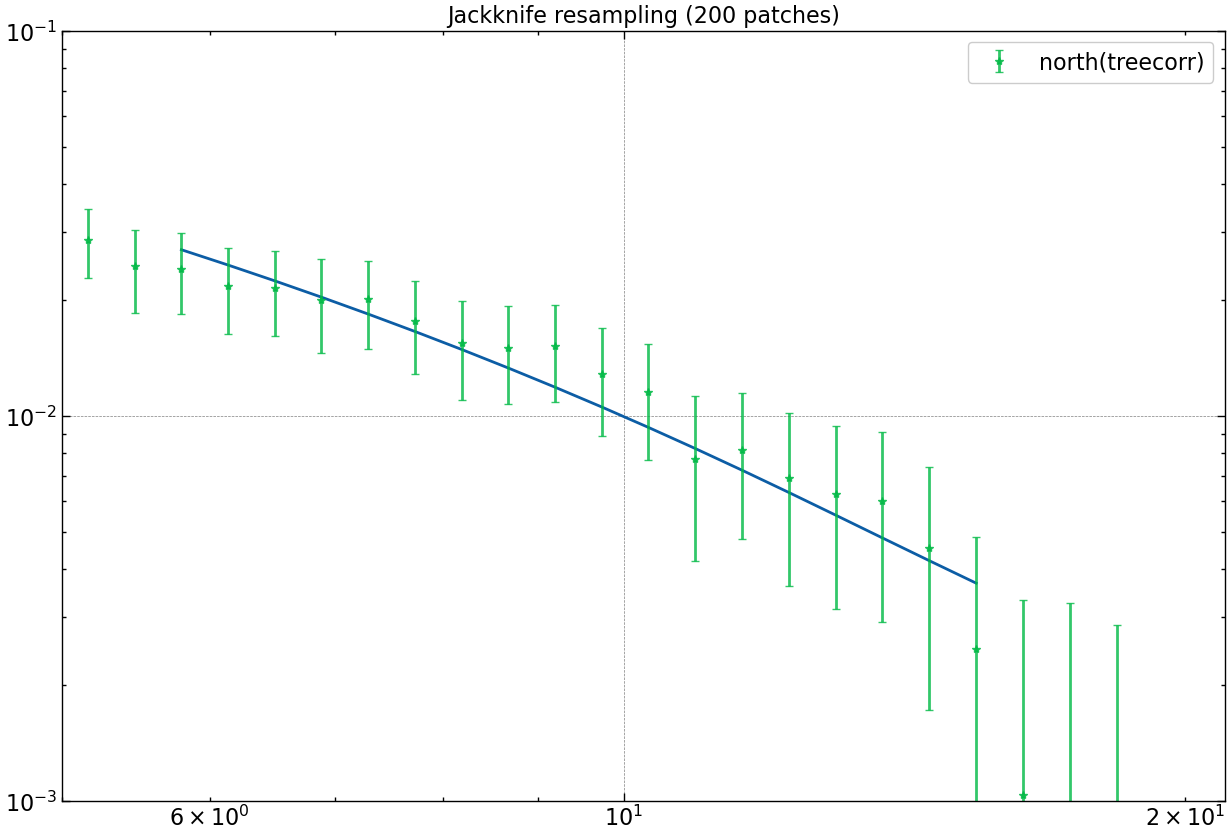

[5.55510997]
[5.55510997]


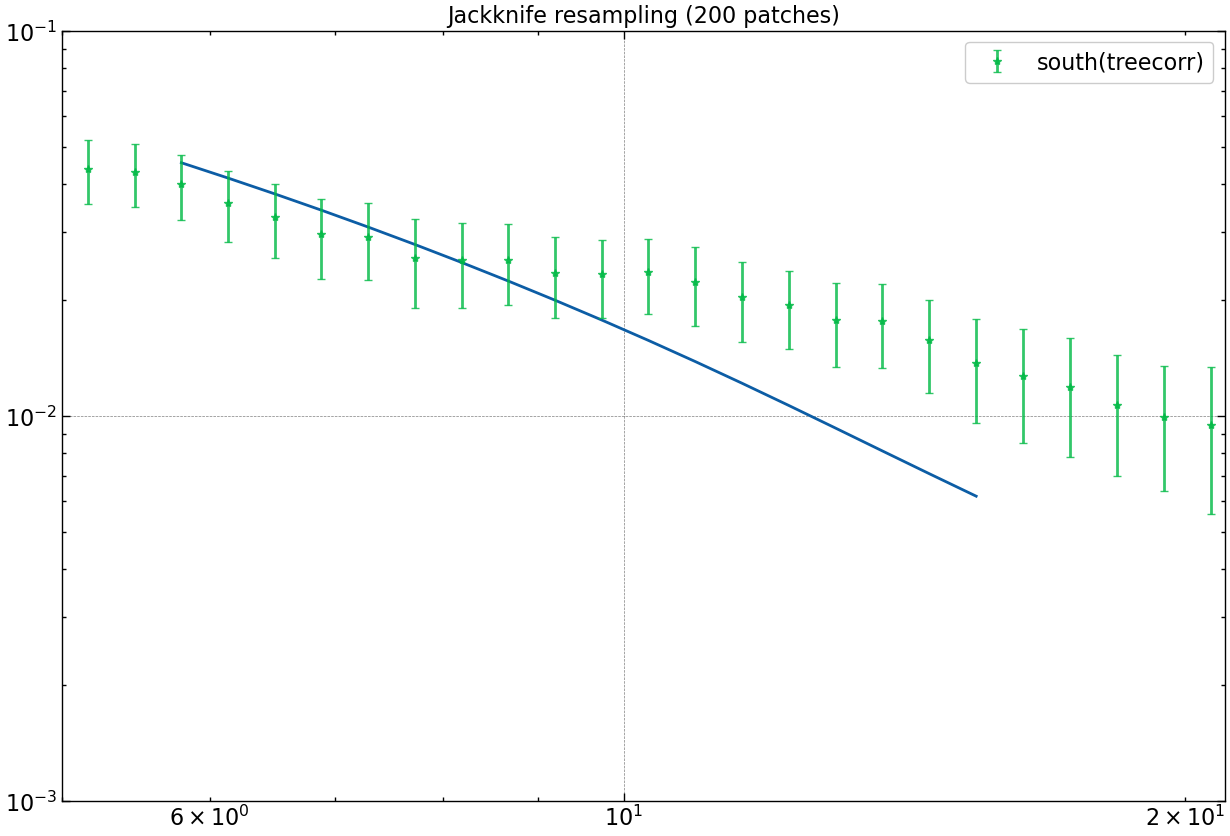

In [ ]:
for file in files_jackknife_200:
    fig, ax = plt.subplots(figsize=(15,10))

    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (200 patches)')
    mask_data= (dat[0]<15.9) & (dat[0]>5.6)
    popt,pcov = cf(wfunc,dat[0][mask_data],dat[1][mask_data])
    print(np.sqrt(popt))
    ax.plot(dat[0][mask_data],wfunc(dat[0][mask_data],*popt))
    ax.errorbar(dat[0],dat[1],yerr=dat[2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
    plt.legend()
    print(popt)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(0.001,0.1)
    plt.xlim(5,21)
    plt.show()

In [ ]:
files_jackknife = [file for file in files if  'jackknife'  in file and 'corrfunc' in file]
files_jackknife

['/user/animesh.sah/w_theta_results/corrfunc_south_jackknife_patches_nside_6_128_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_north_jackknife_patches_nside_6_59_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_north_jackknife_patches_8_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_north_jackknife_patches_59_0.001_to_100.npy',
 '/user/animesh.sah/w_theta_results/corrfunc_full_jackknife_patches_nside_6_180_0.001_to_100.npy']

In [ ]:
w_estimates_south = np.load(files_jackknife[0])[:,1]
w_estimates_north = np.load(files_jackknife[1])[:,1]
w_estimates_full = np.load(files_jackknife[-1])[:,1]

In [ ]:
# for i in range(w_estimates_north.shape[1]):
#     plt.hist(w_estimates_south[:,i],bins=20)
#     #plt.show()

In [ ]:
x_mean_south= np.mean(w_estimates_south,axis=0)
x_mean_north= np.mean(w_estimates_north,axis=0)
x_mean_full = np.mean(w_estimates_full,axis=0)
from matplotlib.colors import LogNorm

C_jk_north=199/200*((w_estimates_north- x_mean_north).T@(w_estimates_north- x_mean_north))
C_jk_south=199/200*((w_estimates_south- x_mean_south).T@(w_estimates_south- x_mean_south))
C_jk_full = 199/200*((w_estimates_full - x_mean_full).T@(w_estimates_full - x_mean_full))
sigma_jk_north=np.sqrt(np.diag(C_jk_north))
sigma_jk_south=np.sqrt(np.diag(C_jk_south))
sigma_jk_full=np.sqrt(np.diag(C_jk_full))

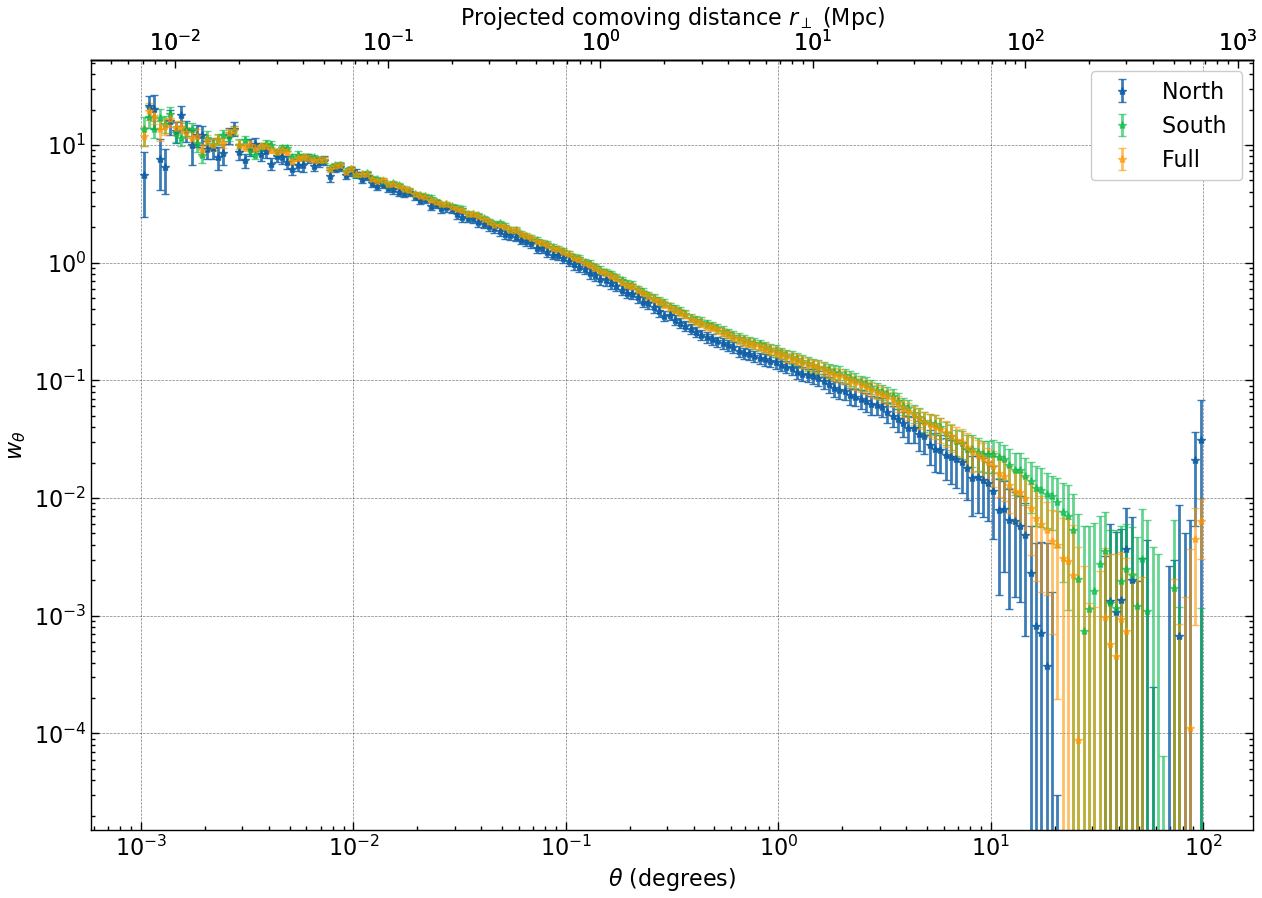

In [ ]:
w_theta_north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy')
w_theta_south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy')
w_theta_full = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy')

fig,ax = plt.subplots(figsize=(15,10))
ax.errorbar(w_theta_north[0], w_theta_north[1], yerr=sigma_jk_north,ls='None',marker='*',capsize=3,label = 'North ',alpha=0.8)
ax.errorbar(w_theta_south[0], w_theta_south[1], yerr=sigma_jk_south,ls='None',marker='*',capsize=3,label = 'South ',alpha=0.6)
ax.errorbar(w_theta_full[0], w_theta_full[1], yerr=sigma_jk_full,ls='None',marker='*',capsize=3,label = 'Full ',alpha=0.6)

secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
plt.legend()
plt.savefig('w_theta_jackknife_north_south.png')
plt.show()

In [ ]:
files_point = np.sort([file for file in files if  'jackknife'  not in file and 'bootstrap' not in file and  '0.001_to_100' in file and 'corrfunc' in file  and 'full' not in file])
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy'],
      dtype='<U65')

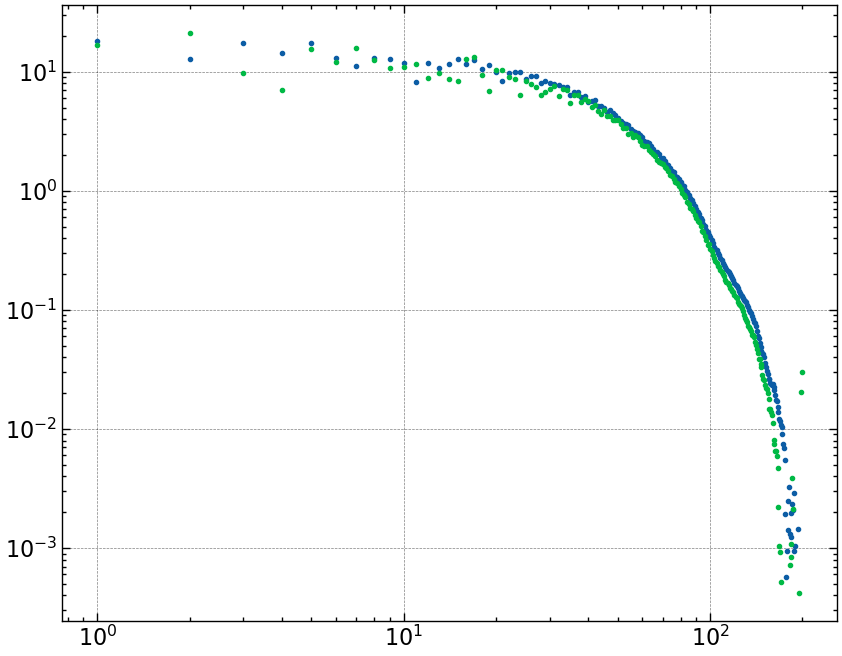

In [ ]:
plt.figure(figsize=(10,8))
plt.loglog(np.mean(w_estimates_south,axis = 0),'.')
plt.loglog(np.mean(w_estimates_north,axis = 0),'.')



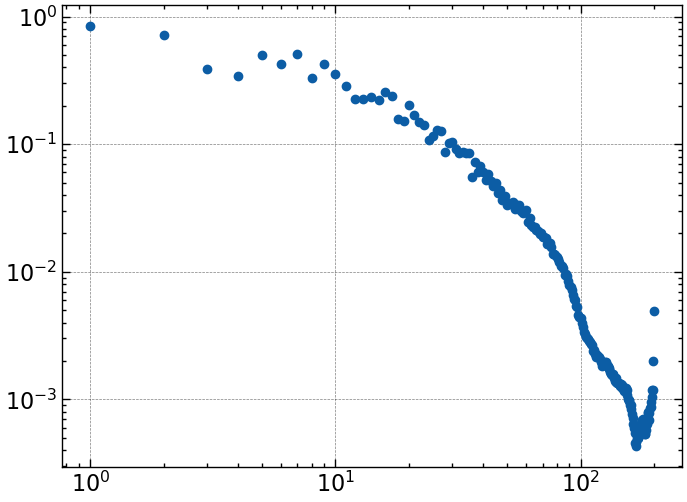

In [ ]:
plt.loglog(np.std(w_estimates,axis = 0),'o')


Text(0.5, 1.0, 'Jackknife resampling')

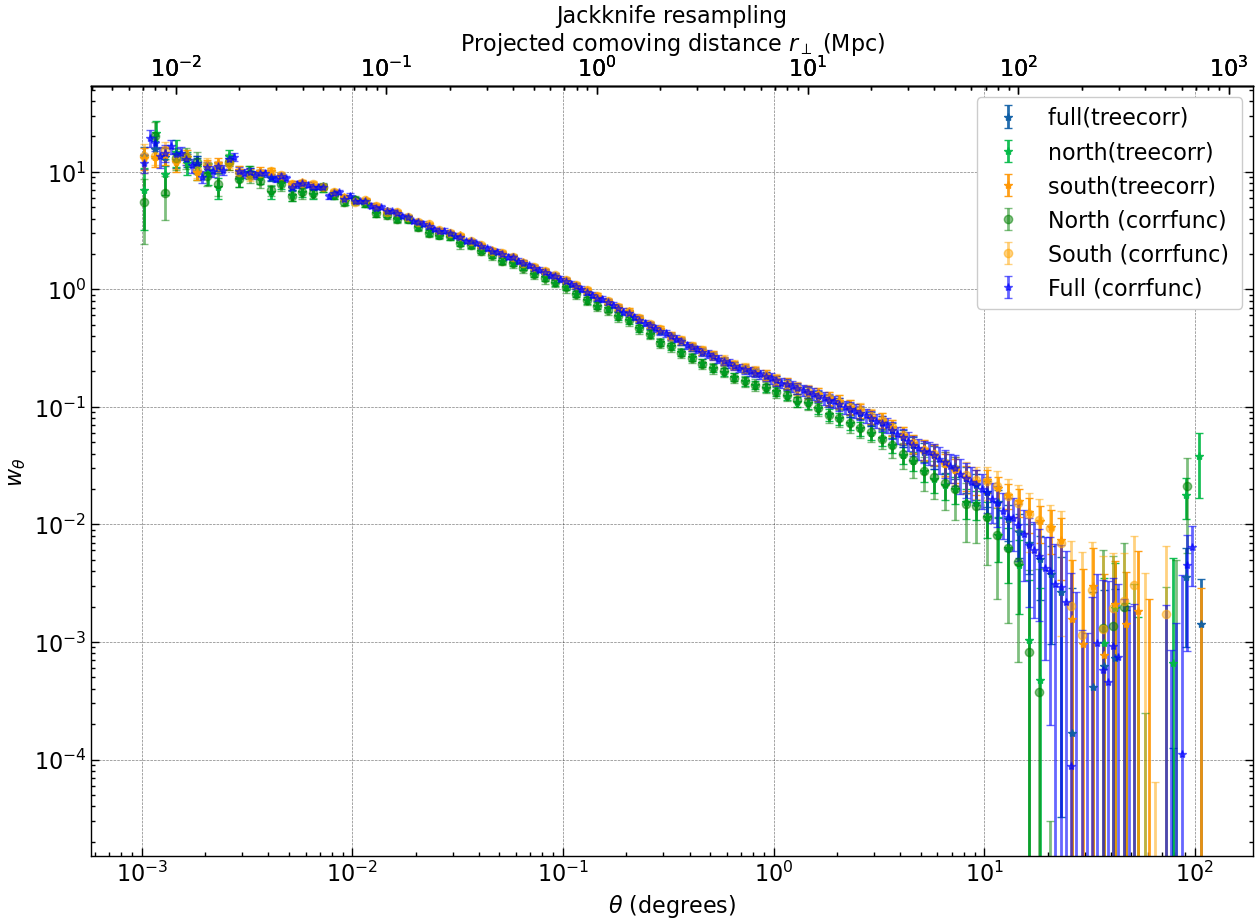

In [ ]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files_jackknife_200 = np.sort([file for file in files if  'jackknife'  in file and '200' in file ])

#files_bootstrap = np.sort([file for file in files if  'bootstrap'  in file])
#part = ['north','south','full']


#{patch: [file for file in files if patch in file] for patch in part}

#plt.figure(figsize=(15,10))
fig, ax = plt.subplots(figsize=(15,10))

for file in files_jackknife_200:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    #ax.set_title('Jackknife resampling (200 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=f'{name} ',marker='*',linestyle='None',capsize=3,alpha=0.9)
ax.set_xscale('log')

ax.set_yscale('log')
ax.errorbar(w_theta_north[0][::2], w_theta_north[1][::2], yerr=sigma_jk_north[::2],ls='None',marker='o',color='green',capsize=3,label = 'North (corrfunc) ',alpha=0.5)
ax.errorbar(w_theta_south[0][::2], w_theta_south[1][::2], yerr=sigma_jk_south[::2],ls='None',marker='o',color='orange',capsize=3,label = 'South (corrfunc)',alpha=0.5)
ax.errorbar(w_theta_full[0], w_theta_full[1], yerr=sigma_jk_full,ls='None',marker='*',color='b',capsize=3,alpha=0.6,label ='Full (corrfunc)')

secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()
plt.title('Jackknife resampling')

In [ ]:
w_theta

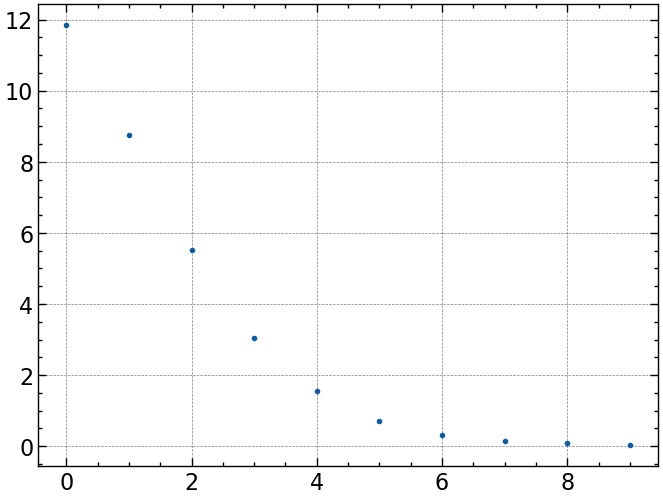

In [ ]:
import pyarrow.parquet as pq
bootstrap = pq.read_table("/user/animesh.sah/DESI_PECVEL/bootstrap_results.parquet")
k = bootstrap.column("bootstrap_test").to_pylist()   # returns list of lists/arrays
lst_boot = np.vstack(k)


mean_lst = np.mean(lst_boot,axis=0)
cov_boot = (1/9999)*((lst_boot- mean_lst).T@(lst_boot- mean_lst))
sigma_boot=np.sqrt(np.diag(cov_boot))
plt.plot(mean_lst,'.')
# lst_boot
# mean=[]
# std=[]
# for i in range(20):
#     plt.hist(lst_boot[:,i],bins=30,edgecolor='k',alpha=0.5)
#     #plt.axvline(W[i],color='r',ls='-.')
#     mean.append(lst_boot[:,i].mean())
#     std.append(lst_boot[:,i].std())
#     plt.show()

In [ ]:
w

In [3]:
north = np.load('/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_10.npy')
south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_none_patches_100_0.001_to_10.npy')

In [121]:
w_0_03=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.03.npy')
w_min0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_-0.0234.npy')
w_0_04=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.04.npy')
w_0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.023.npy')


In [10]:
w_min_0_04 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_min_0.04_v2.npy')
w_0_04 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.04_v2.npy')
w_0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.0234_v2.npy')
w_0_01 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.01_v2.npy')

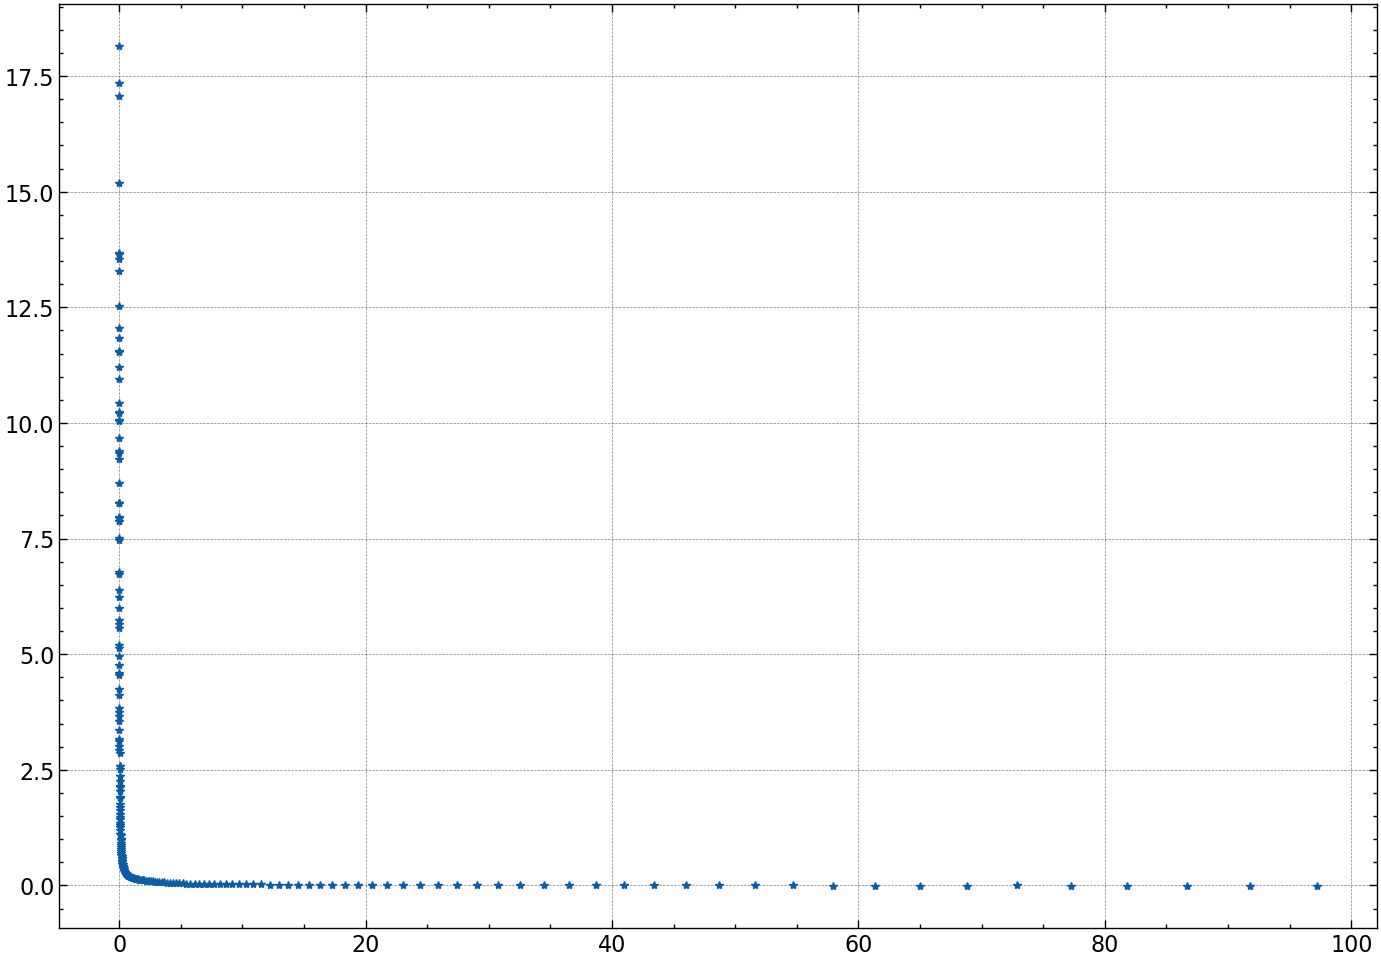

In [11]:
color = ['k','r','b','g']
fig,ax = plt.subplots(figsize=(17,12))
for file in ['/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy']: 
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    if  'corrfunc' in name:
        ax.plot(dat[0],dat[1],label=name,marker='*',linestyle='None')
    else: 
        ax.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')

In [12]:
north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy')
south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy')

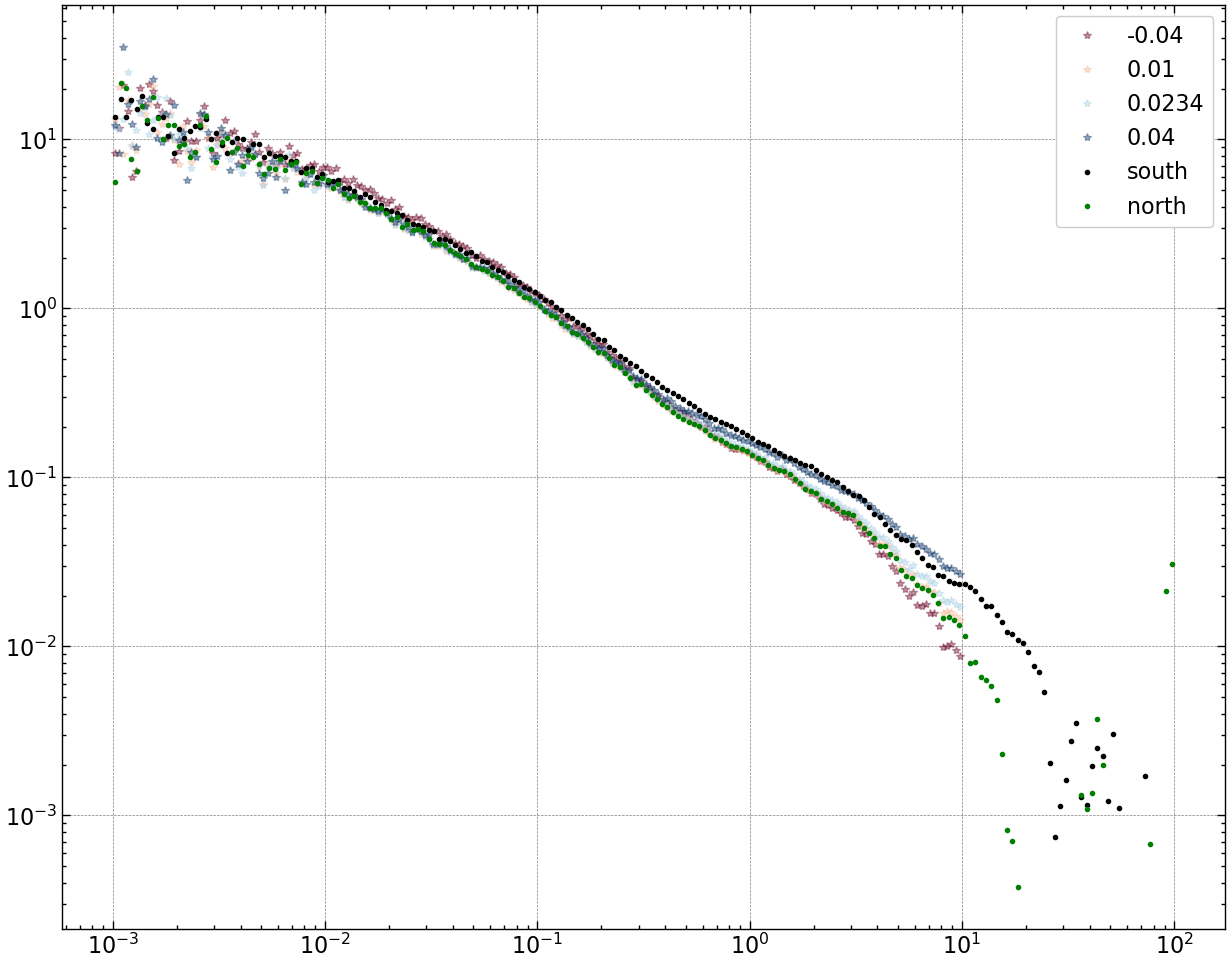

In [18]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))

plt.figure(figsize=(15,12))
plt.plot(w_min_0_04[0],w_min_0_04[1],'*',label='-0.04',color=colors[0],alpha=0.4)
plt.plot(w_0_01[0],w_0_01[1],'*',label='0.01',color=colors[1],alpha=0.4)
plt.plot(w_0_0234[0],w_0_0234[1],'*',label='0.0234',color=colors[2],alpha=0.4)

plt.plot(w_0_04[0],w_0_04[1],'*',label='0.04',color = colors[3],alpha=0.4)
# plt.plot(w_0_0234[0],w_0_0234[1],'*')
# plt.plot(w_0_03[0],w_0_03[1],'*')
plt.xscale('log')
plt.yscale('log')
dat = np.load(file)
plt.plot(south[0],south[1],marker='.',linestyle='None',label='south',color='k')
plt.plot(north[0],north[1],marker='.',linestyle='None',label='north',color='g')
plt.plot()
plt.legend()

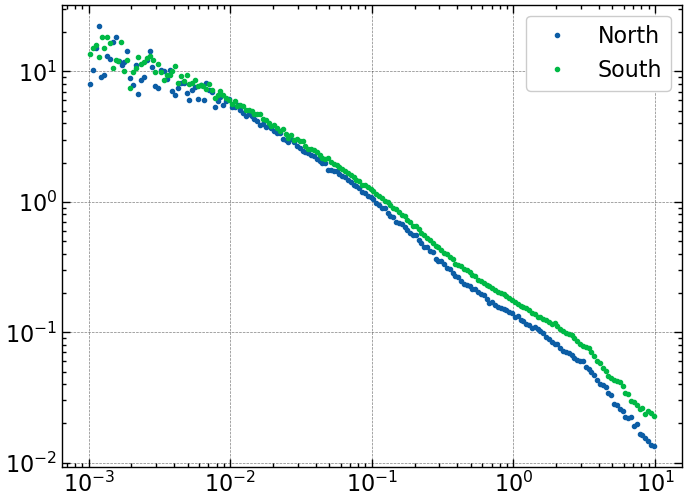

In [ ]:
plt.plot(north[0],north[1],'.',label='North')
plt.plot(south[0],south[1],'.',label='South')
plt.xscale('log')
plt.yscale('log')
plt.legend()B

In [21]:
north[:,3]

array([123.50527837,   1.        ,  -1.50005332, ...,  -4.00010663,
        -1.50005332,   1.        ])

In [41]:
w_theta[1]

array([9.18181818e+00, 1.12777778e+01, 1.44375000e+01, 1.65769231e+01,
       1.31428571e+01, 8.40000000e+00, 9.28571429e+00, 1.91578947e+01,
       1.34324324e+01, 1.35000000e+01, 9.02325581e+00, 1.05000000e+01,
       1.05833333e+01, 1.75000000e+01, 1.51176471e+01, 8.41935484e+00,
       1.10877193e+01, 7.69491525e+00, 8.02531646e+00, 9.33333333e+00,
       1.18823529e+01, 1.23513514e+01, 1.27346939e+01, 7.04166667e+00,
       8.28260870e+00, 1.24876033e+01, 9.04945055e+00, 1.00066225e+01,
       1.14000000e+01, 7.15207373e+00, 7.37209302e+00, 7.18613139e+00,
       8.11743772e+00, 8.12933754e+00, 7.16613419e+00, 5.74358974e+00,
       7.09336609e+00, 7.78160920e+00, 6.27494908e+00, 7.62962963e+00,
       5.66019417e+00, 7.93076923e+00, 7.30952381e+00, 6.98505435e+00,
       5.51814768e+00, 6.15367728e+00, 6.33658537e+00, 5.80269490e+00,
       5.75589910e+00, 6.34029389e+00, 5.73665480e+00, 5.51684679e+00,
       5.43557583e+00, 4.95301328e+00, 4.64045476e+00, 4.47918437e+00,
      

In [38]:
w_theta= np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10.npy')
w_theta_by_5 =

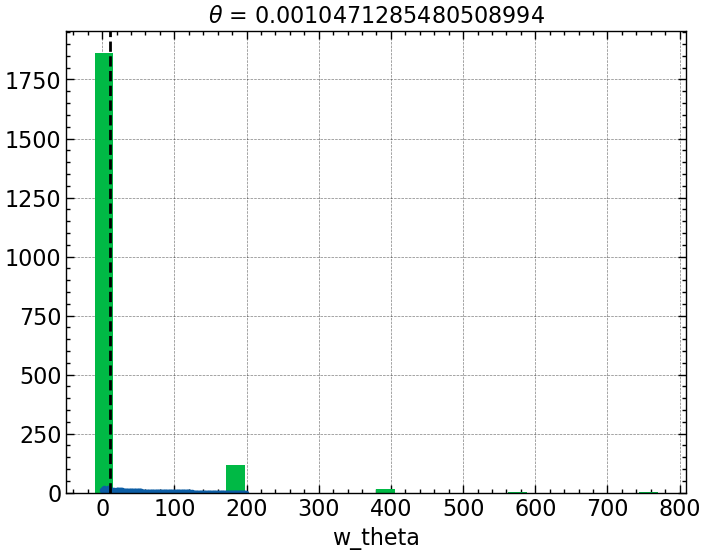

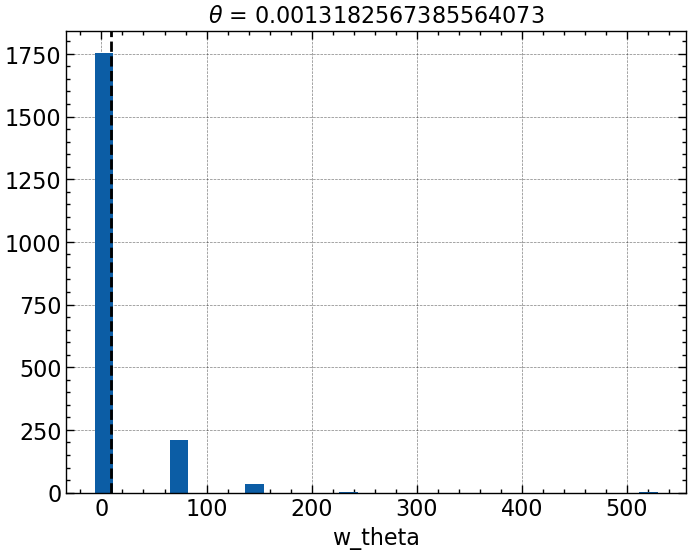

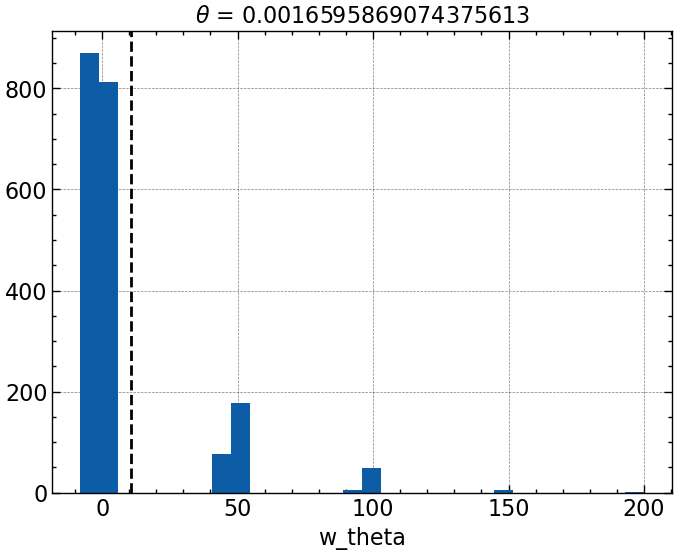

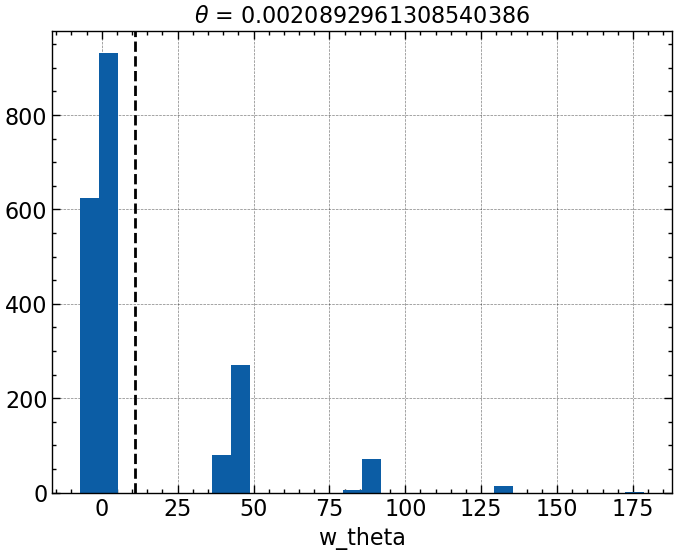

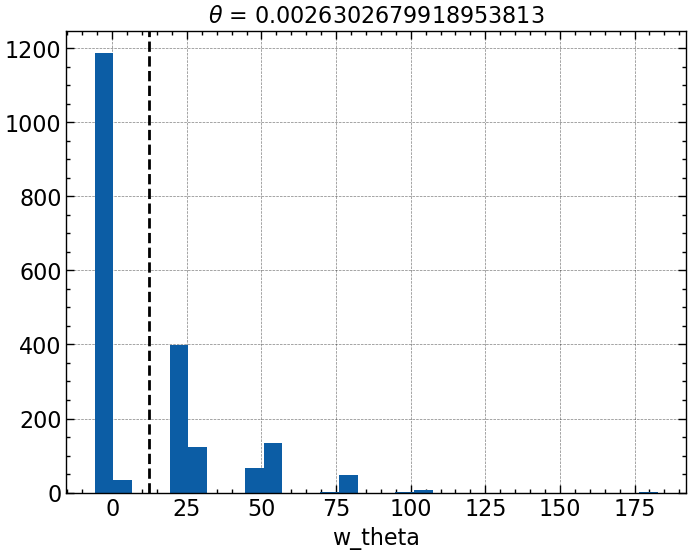

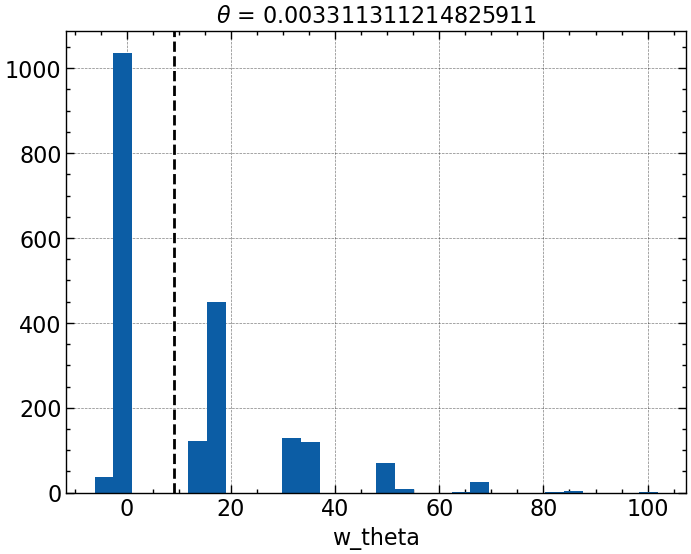

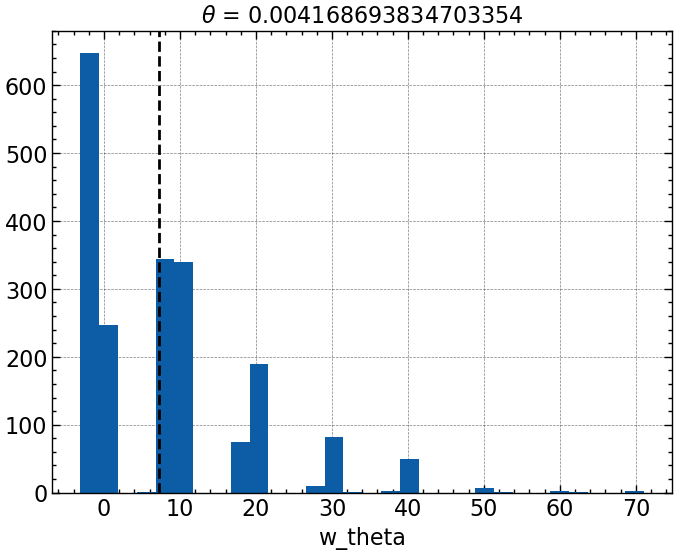

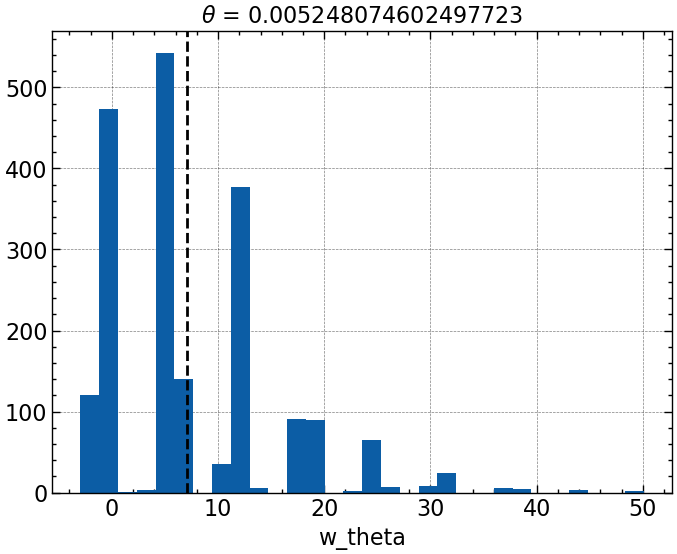

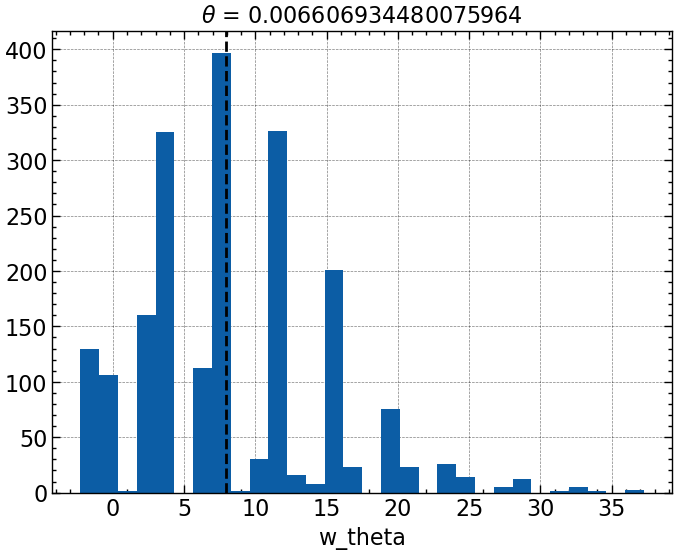

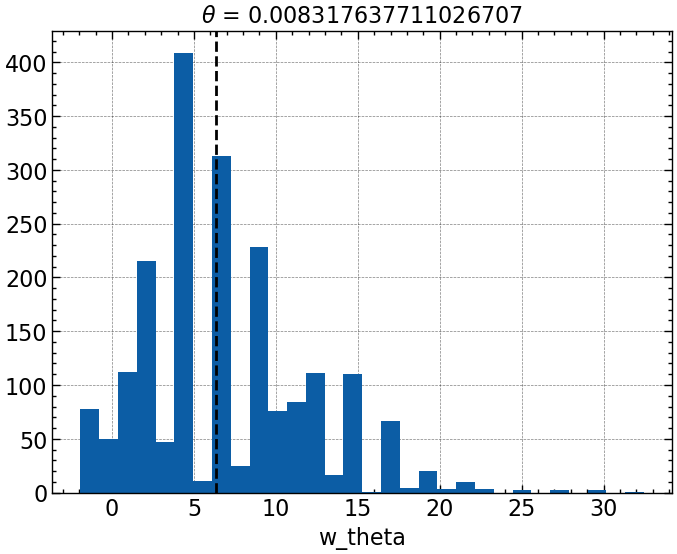

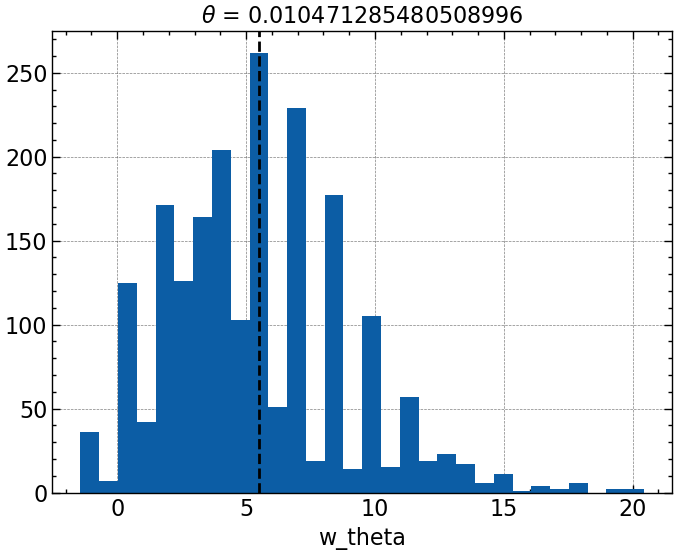

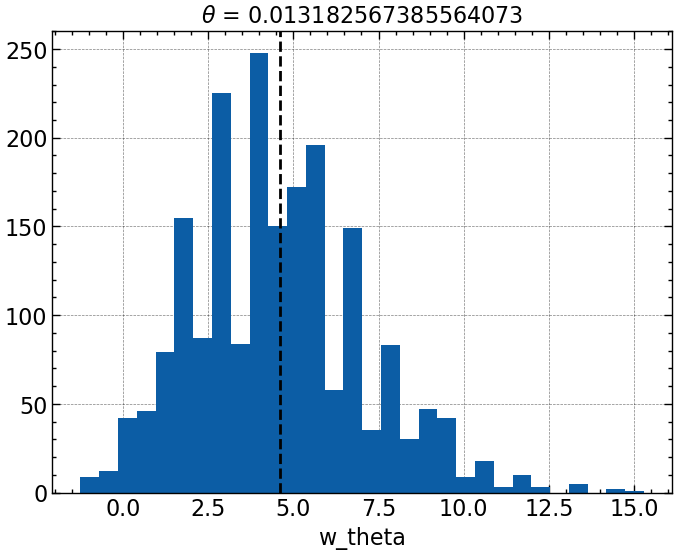

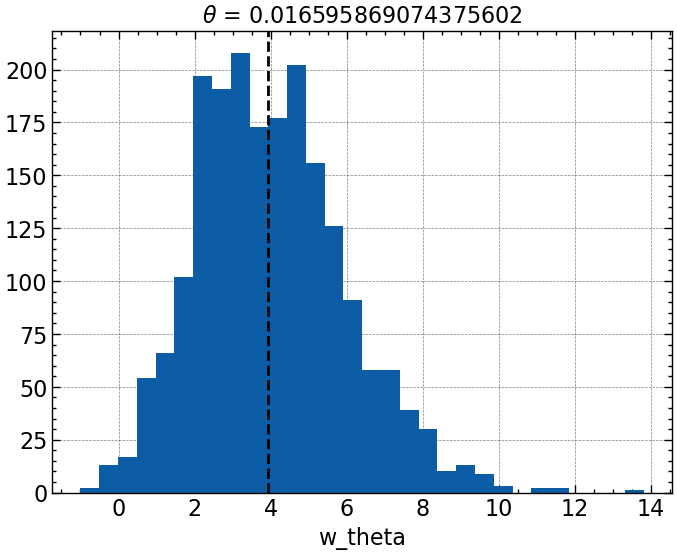

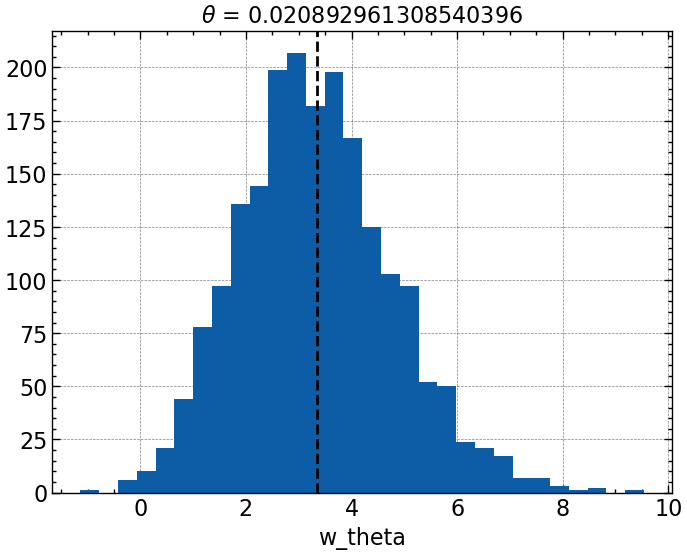

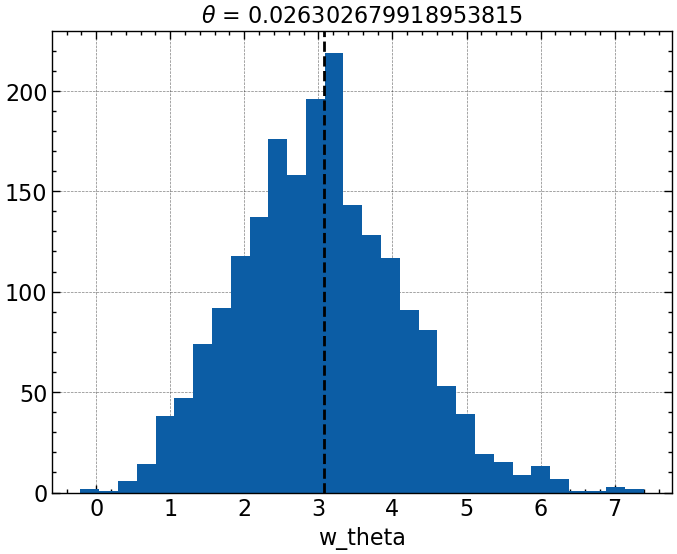

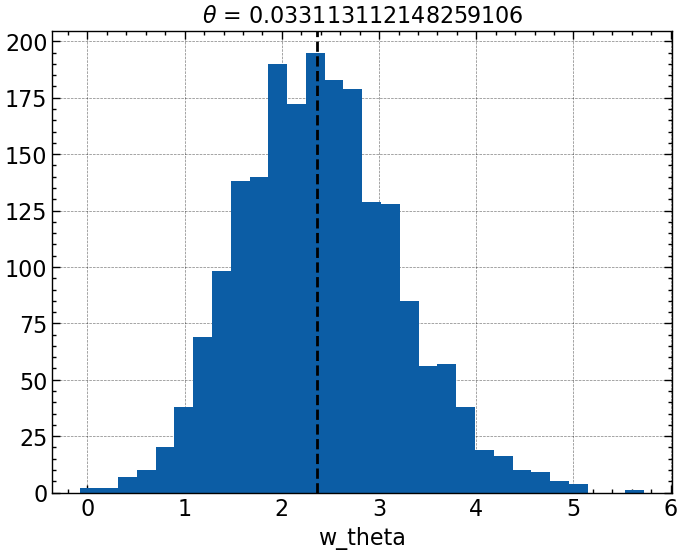

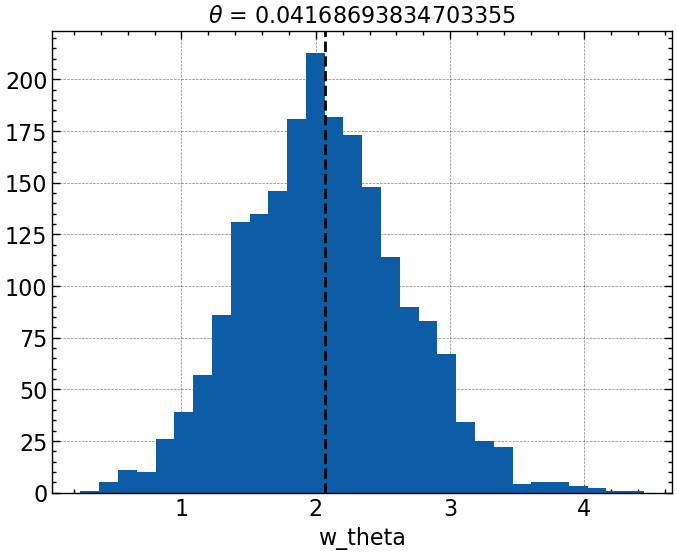

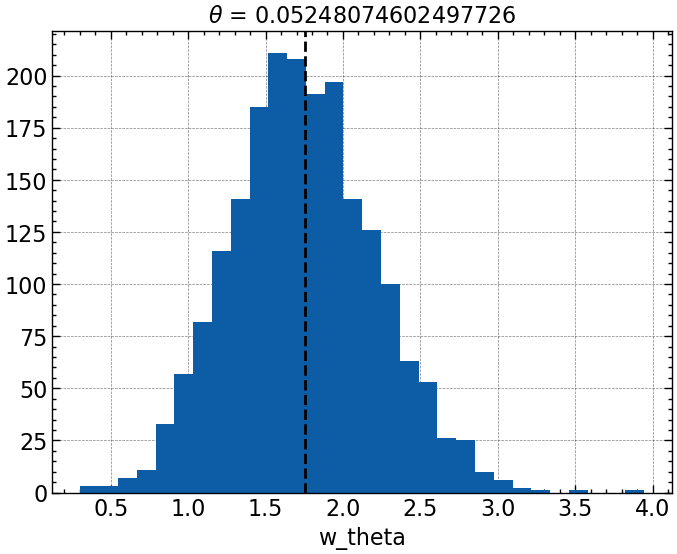

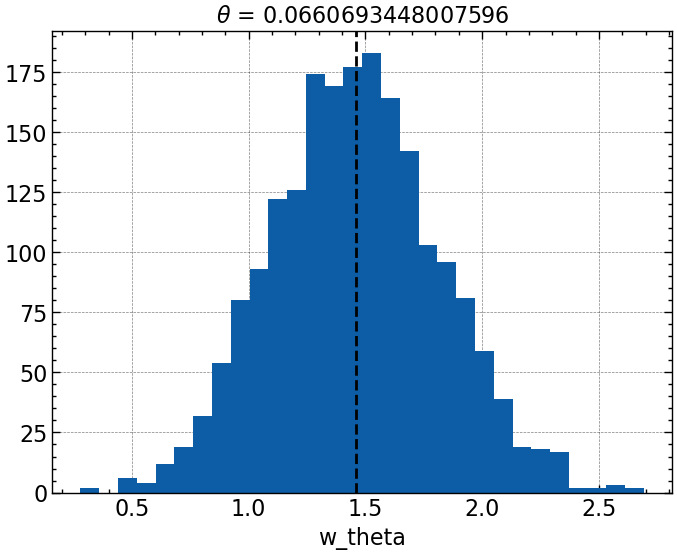

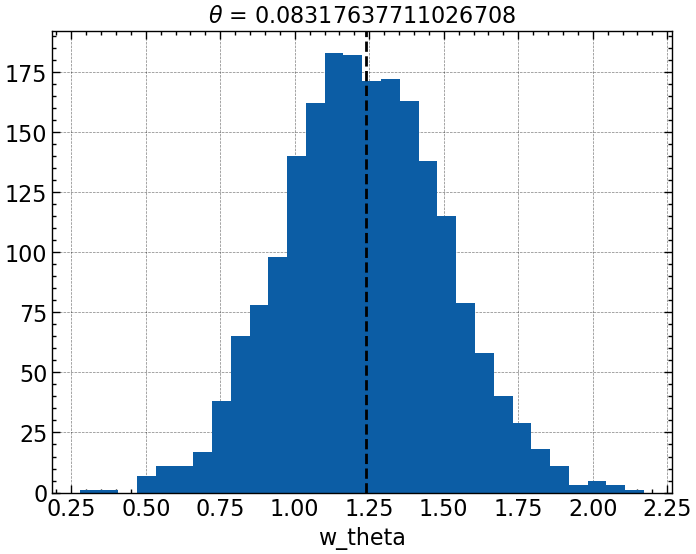

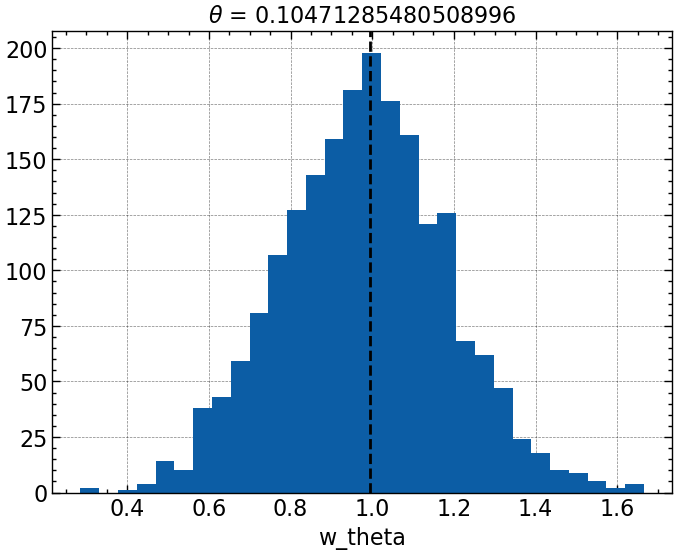

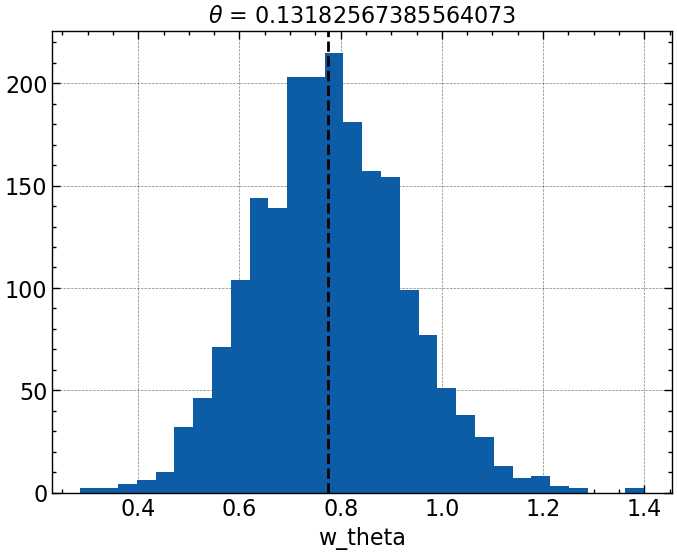

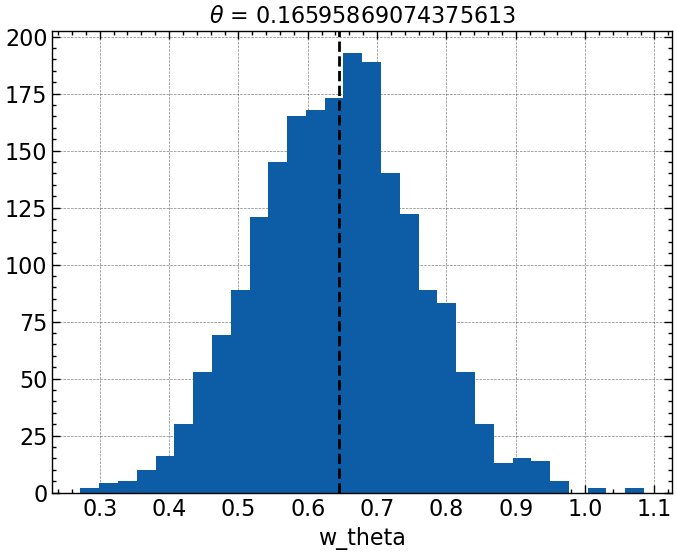

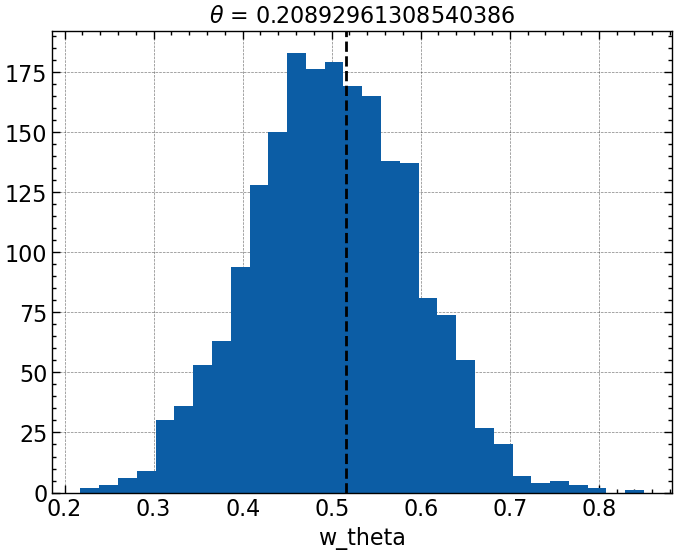

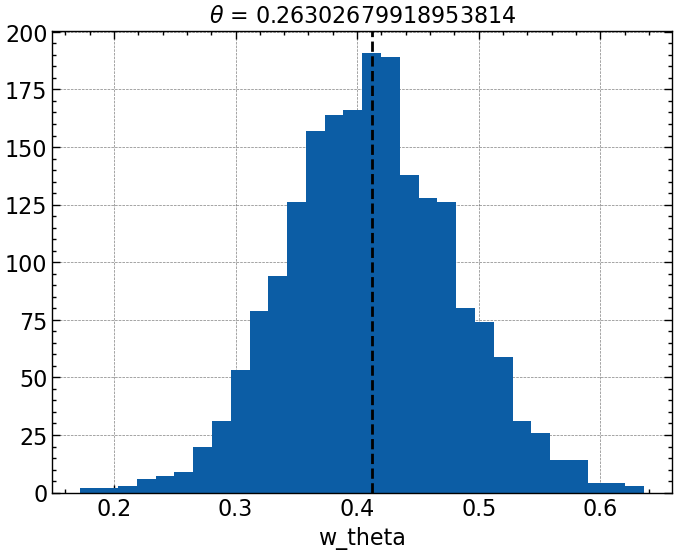

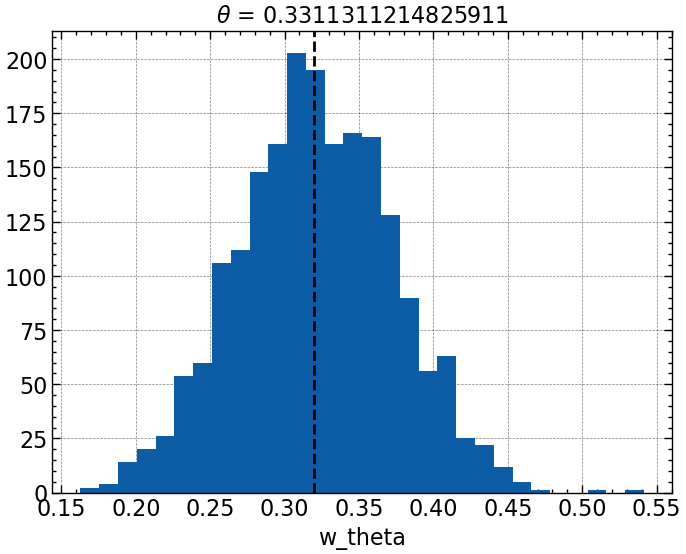

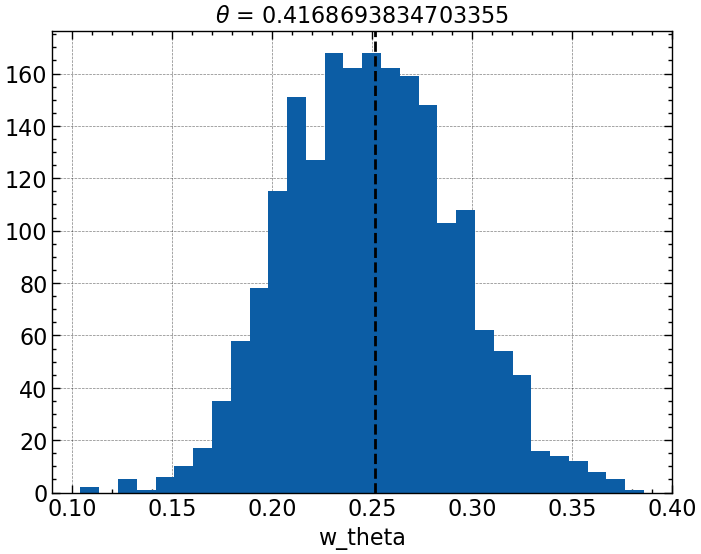

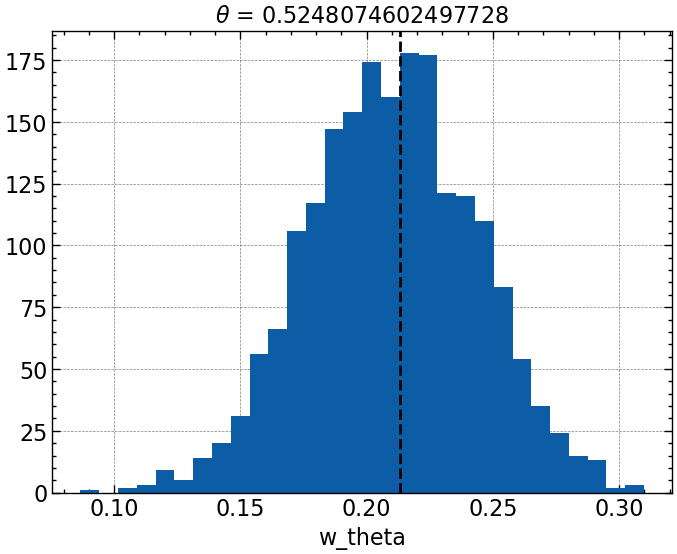

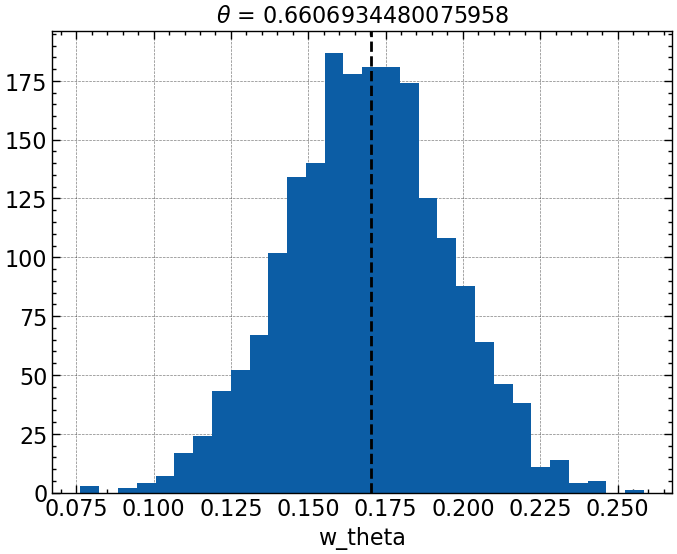

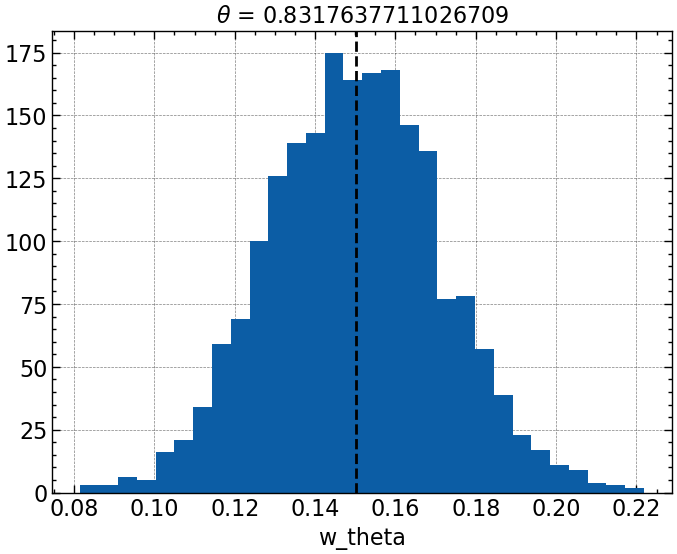

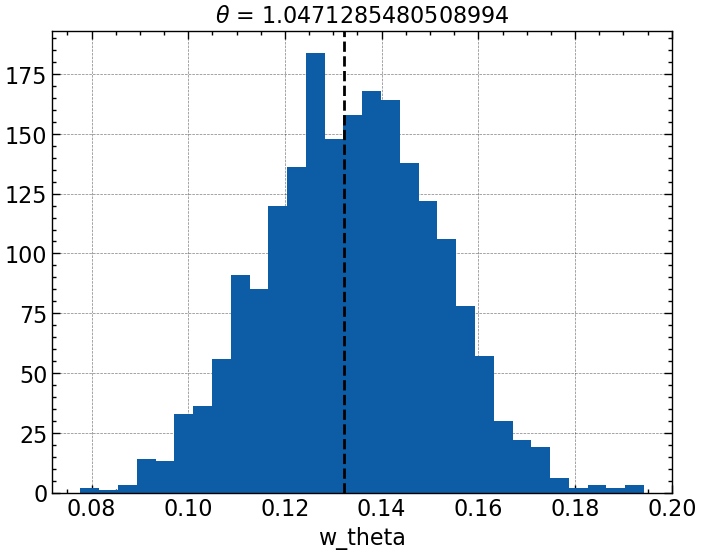

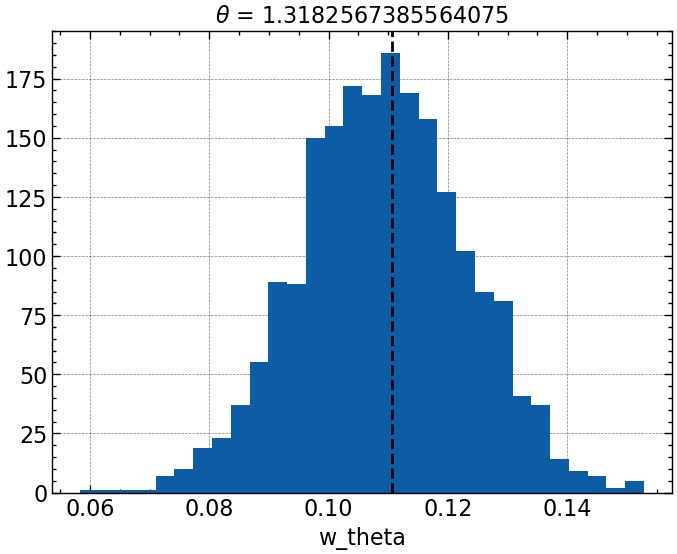

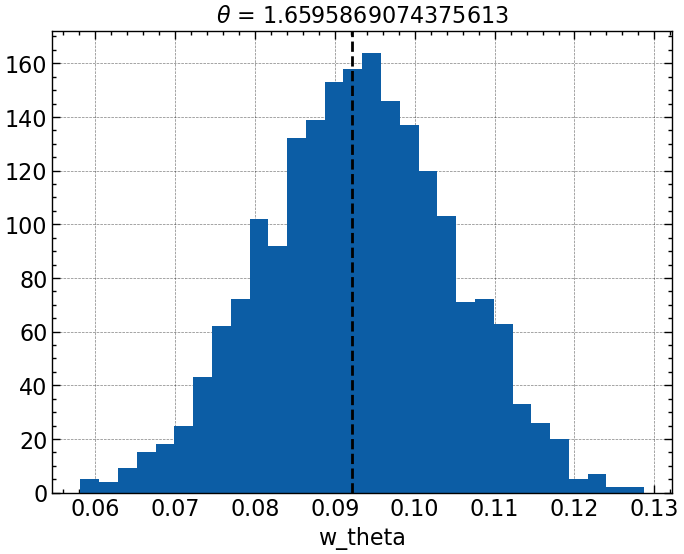

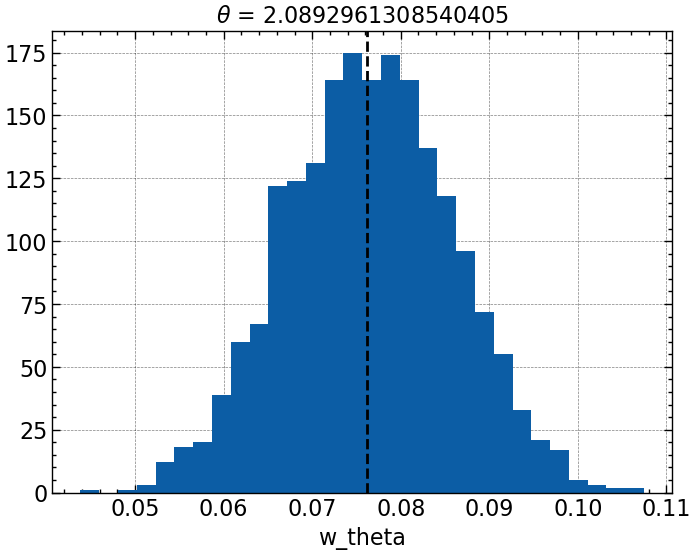

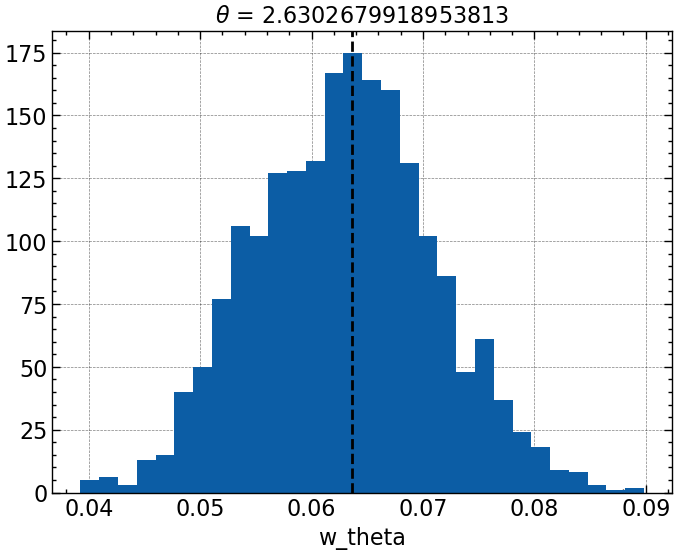

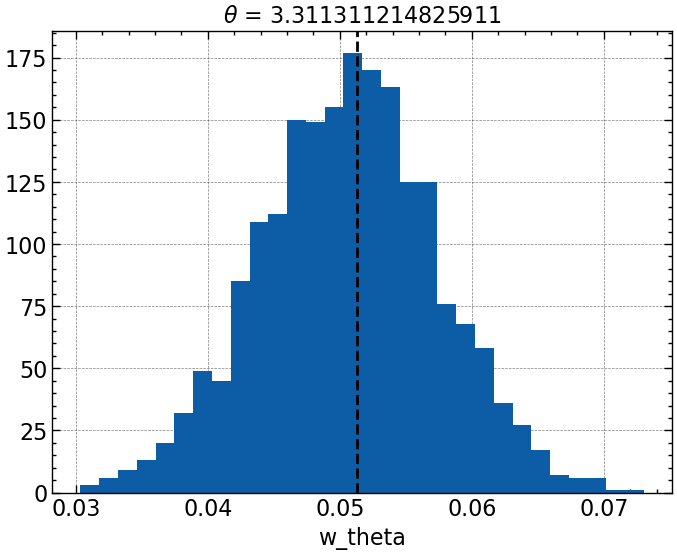

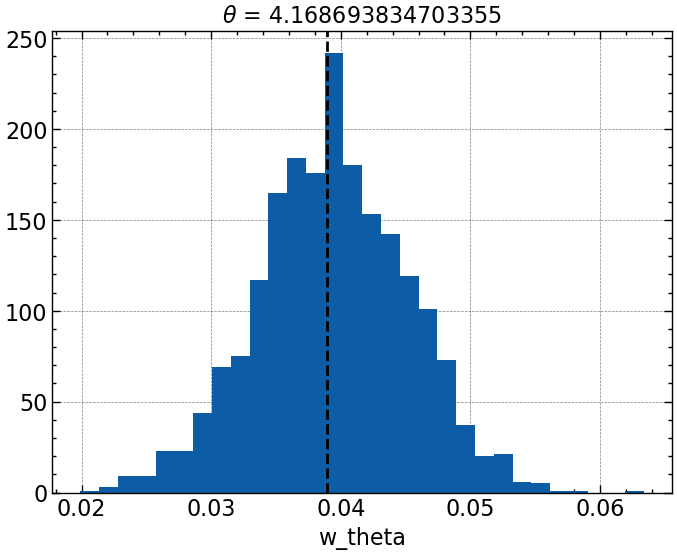

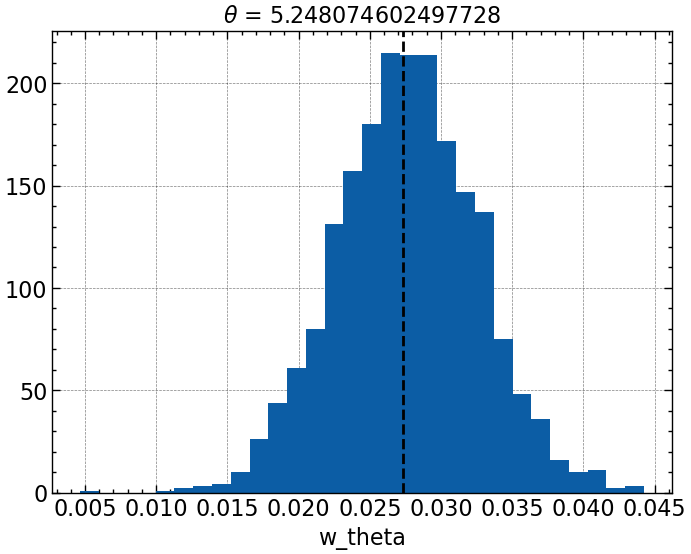

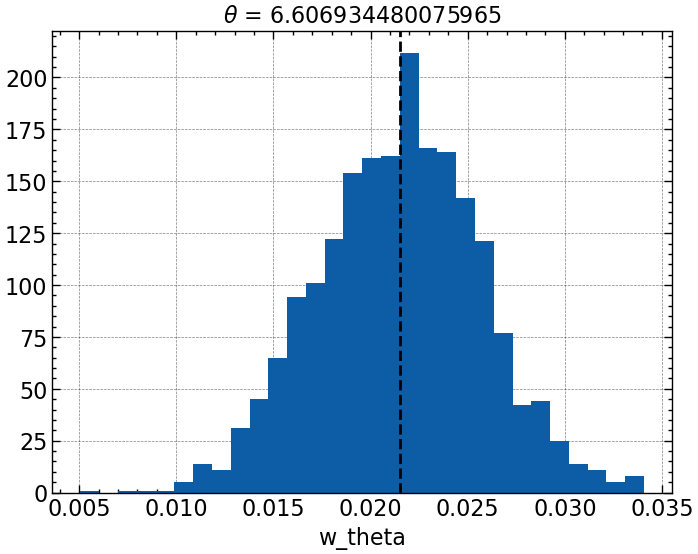

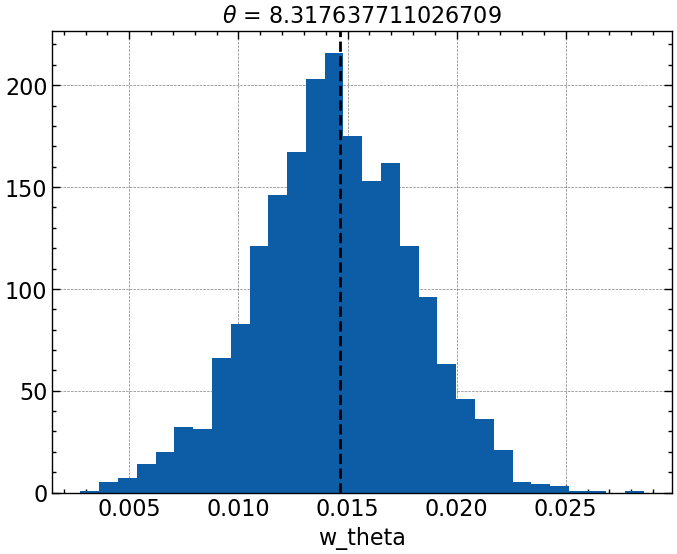

In [67]:
north=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap__num_bootstrap_2000_0.001_to_10_v2.npy')
th=np.logspace(np.log10(0.001), np.log10(10), 200+1 )
plt.plot(np.mean(north,axis=0),'.')
for i in range(1,north.shape[1],5):
    plt.hist(north[:,i],bins=30)
    plt.title(r'$\theta$ = '+str(th[i]))
    plt.axvline(w_theta[1][i],color='k',ls='--')
    plt.xlabel('w_theta')
    plt.show()

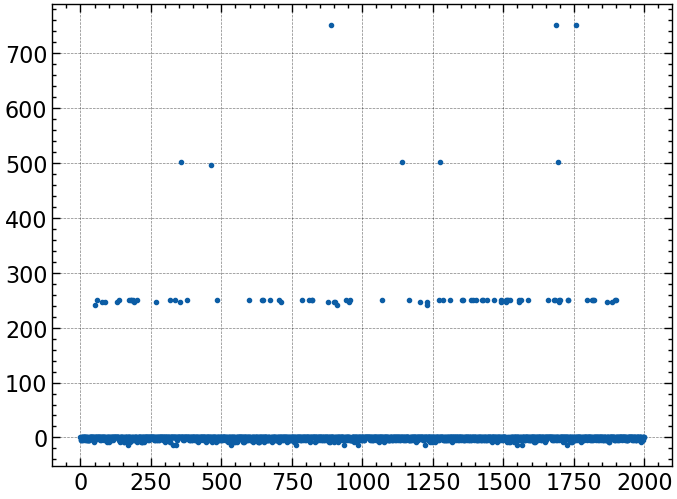

In [ ]:
plt.plot(north[:,0],'.')

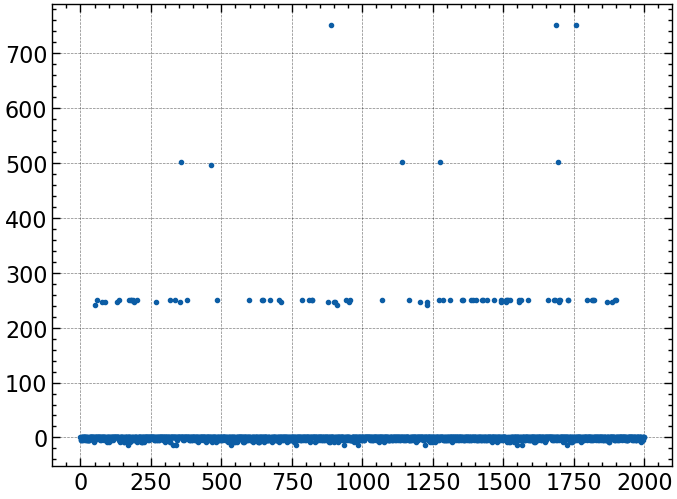

In [ ]:
plt.plot(north[:,0],'.')

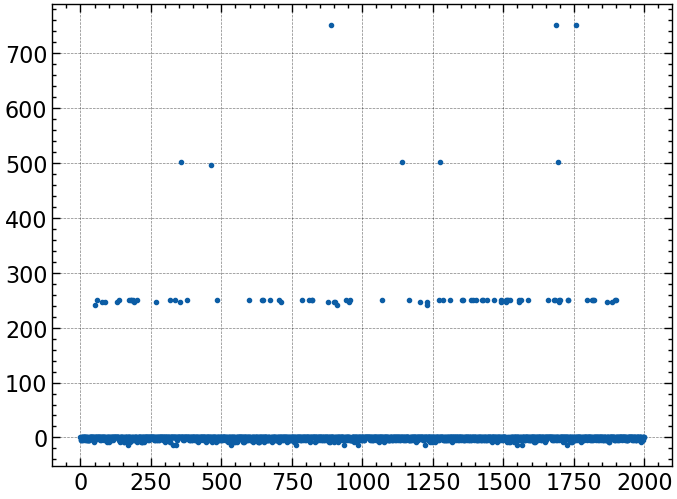

In [ ]:
plt.plot(north[:,0],'.')

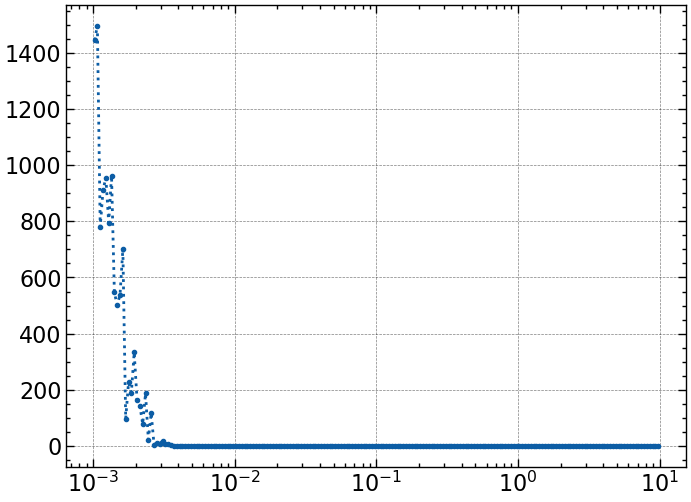

In [56]:

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(north[:,i]==1) for i in range(north.shape[1])],'.:')
#plt.yscale('log')
plt.xscale('log')

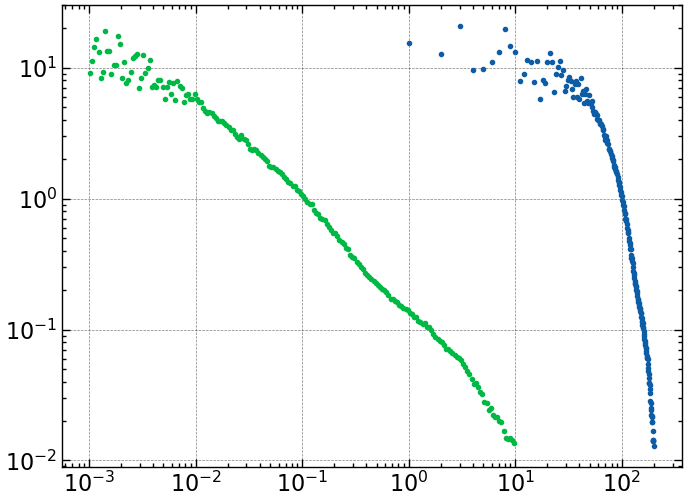

In [45]:
plt.plot(north.mean(axis=0),'.')
plt.plot(w_theta[0],w_theta[1],'.')
plt.xscale('log')
plt.yscale('log')

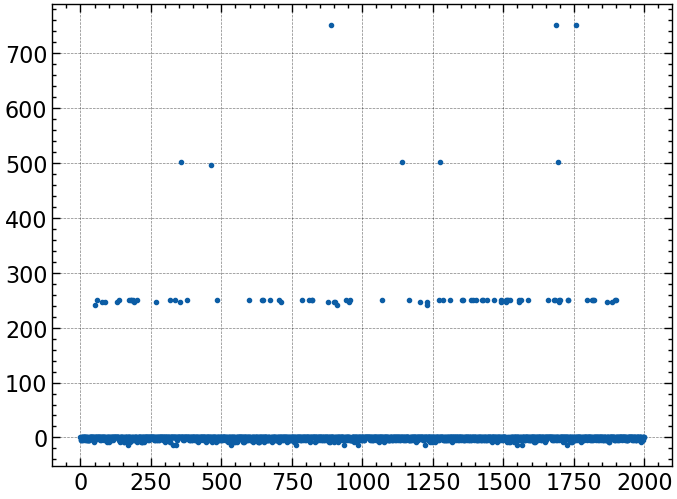

In [29]:
plt.plot(north[:,0],'.')

In [30]:
np.count_nonzero(north[0]==1)

3

In [103]:
w_theta_north_by5 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by5.npy')
w_theta_north_by10 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by10.npy')
w_theta_north_by2 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by2.npy')
w_theta_north_by1 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by1.npy')
th = np.logspace(np.log10(0.001), np.log10(1), 200+1 )

(0.0009, 0.01)

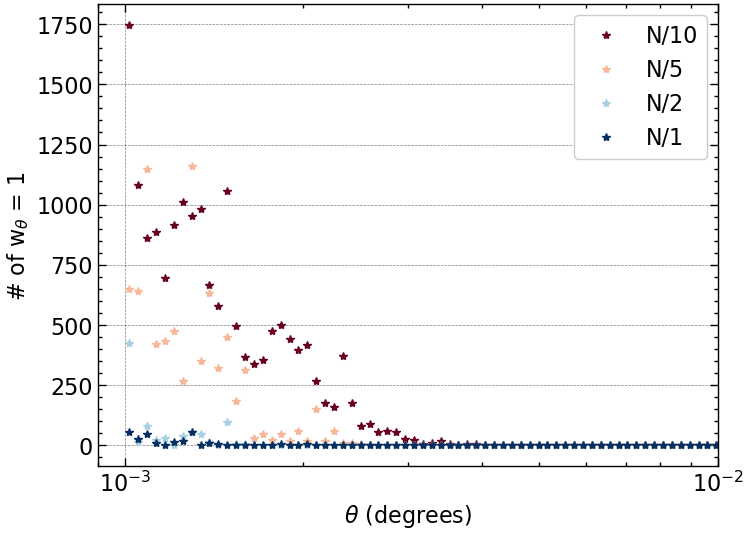

In [113]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by10[:,i]==1) for i in range(w_theta_north_by10.shape[1])],'*',color=colors[0],label='N/10')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by5[:,i]==1) for i in range(w_theta_north_by5.shape[1])],'*',color=colors[1],label='N/5')
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by2[:,i]==1) for i in range(w_theta_north_by2.shape[1])],'*',color=colors[2],label='N/2')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by1[:,i]==1) for i in range(w_theta_north_by1.shape[1])],'*',color=colors[3],label='N/1')

plt.xscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'# of w$_\theta$ = 1')
plt.legend()
plt.xlim(9e-4,1e-2)
#plt.title('For N/5')
#plt.yscale('log')